# Topology Analysis of Australian ISP networks


## Read in files and make the graph object

In [1]:
# function to read the nodes and edges of one layer and add into the network with the correct terminology
import pandas as pd
import networkx as nx
import matplotlib as mpl
import matplotlib.pyplot as plt

# directories
NODE_DIR = 'nodes.csv'
EDGE_DIR = 'edge_list.csv'
SRG_DIR = 'srgs.csv'

IXP_DIR = 'ixps.csv'
SITE_DIR = 'sites.csv'

# list of the isps and corresponding colours
ISP_LIST = ['aarnet', 'abb', 'optus', 'superloop','telstra', 'vocus']
ISP_LABELS = {'aarnet': 'AARNet', 'abb': 'ABB', 'optus': 'Optus', 'superloop': 'Superloop','telstra': 'Telstra', 'vocus': 'Vocus'}

OKABE_ITO = [
    "#E69F00", # Orange
    "#56B4E9", # Sky Blue
    "#009E73", # Bluish Green
    "#F0E442", # Yellow
    "#0072B2", # Blue
    "#D55E00", # Vermillion
    "#CC79A7", # Reddish Purple
    "#000000"  # Black
]
ISP_COLOURS = {"aarnet": OKABE_ITO[0], "abb": OKABE_ITO[2], "optus": OKABE_ITO[4], "telstra": OKABE_ITO[6], "ixp": OKABE_ITO[7], "superloop": OKABE_ITO[5], "vocus": OKABE_ITO[1]}
ISP_STYLES = {"aarnet": 'o', "abb": '^', "optus": 's', "telstra": 'p', "ixp": 'd', "superloop": 'h', "vocus": 'v'}


# list of rail and road and corresponding colours
colors = mpl.colormaps['Dark2'].colors
EDGE_COLOURS = {'sub': colors[0], 'road': colors[1], 'rail': colors[4], 'rail_road': colors[2], 'mix': colors[3]}
EDGE_STYLES = {'sub': '-', 'road': ':', 'rail': '--', 'rail_road': '--', 'mix': '-.'}
EDGE_LABELS = {'sub': 'Submarine', 'road': 'Road', 'rail': 'Rail', 'rail_road': 'Rail and Road', 'mix': 'Mix'}

# list of conservative vs ideal and corresponding colours
srg_colours = mpl.colormaps['Paired'].colors
SRG_COLOURS = {'ideal': srg_colours[0], 'conservative': srg_colours[1]}
SRG_STYLES = {'ideal': '.', 'conservative': 's'}

# read in edge list, sites, srgs, ixps, nodes
node_df = pd.read_csv(NODE_DIR)
edge_df = pd.read_csv(EDGE_DIR)
srg_city_df = pd.read_csv(SRG_DIR)
ixp_df = pd.read_csv(IXP_DIR)
site_df = pd.read_csv(SITE_DIR, comment='#')


# add edge identifier specific to isp as column
edge_df['key'] = edge_df['isp'] + "." + edge_df["link_id"]

# function: build a graph per ISP
def build_isp_graph(nodes_df: pd.DataFrame,
                    edges_df: pd.DataFrame,
                    sites_df: pd.DataFrame) -> nx.MultiGraph:
    # create the multigraph
    G = nx.MultiGraph()
    
    # add nodes first, including site information
    for _, row in nodes_df.iterrows():
        node_id = row['node_id']
        isp = row['isp']
        site_row = sites_df[sites_df['site_id']==node_id]
        G.add_node(
            (node_id,isp),
            layer=f"isp:{isp}",
            isp=isp,
            site_id=node_id,
            lat=site_row["lat"],
            lon=site_row["lon"],
            city=site_row["city"],
            kind=site_row["kind"],
            population=site_row["population"],
            ixp=0
        )
    
    # add edges along with attributes (edge metadata)
    for _, row in edges_df.iterrows():
        isp = row['isp']
        u = (row["u"],isp)
        v = (row["v"],isp)
        key = row['key']
        attrs = row.drop(labels=["link_id","u","v","key"]).to_dict()
        # Use link_id as the MultiGraph key so parallel edges don't overwrite
        G.add_edge(u, v, key=key, **attrs)

    return G

# run the function, creating the full network
G_full = build_isp_graph(node_df, edge_df, site_df)

print(G_full)
print("Nodes:", G_full.number_of_nodes(), "Edges:", G_full.number_of_edges())

# function: add ixp edges between the layers
def attach_ixps(G: nx.MultiGraph,
                ixp_df: pd.DataFrame,
                site_df: pd.DataFrame) -> nx.MultiGraph:
    
    # add IXP nodes first
    ixps = ixp_df['ixp']
    for ixp in ixps:
        # get site information
        site_row = site_df[site_df['site_id']==ixp]
        # add to graph
        G.add_node(
            (ixp,'ixp'),
            layer=f"ixp",
            isp='ixp',
            site_id=ixp,
            lat=site_row["lat"],
            lon=site_row["lon"],
            city=site_row["city"],
            kind=site_row["kind"],
            population=site_row["population"],
            ixp=0
        )

    # cycle through each ISP and required edges
    for isp in ISP_LIST:
        # go through the corresponding IXPs belonging to each ISP
        for ixp in list(ixp_df['ixp'][pd.Series(ixp_df[isp]).astype(bool)]):
            u = (ixp,'ixp')
            v = (ixp,isp)
            key = isp + ".ixp."+ ixp 
            G.add_edge(u, v, key=key)
            G.nodes[v]['ixp'] = 1
            G.nodes[u]['ixp'] = G.nodes[u]['ixp'] + 1
    return G

# add ixp edges to graph and print details
G_full = attach_ixps(G_full,ixp_df,site_df)

print(G_full)
print("Nodes:", G_full.number_of_nodes(), "Edges:", G_full.number_of_edges())

MultiGraph with 59 nodes and 131 edges
Nodes: 59 Edges: 131
MultiGraph with 67 nodes and 171 edges
Nodes: 67 Edges: 171


## Create plots of the graph
### Spring Layout

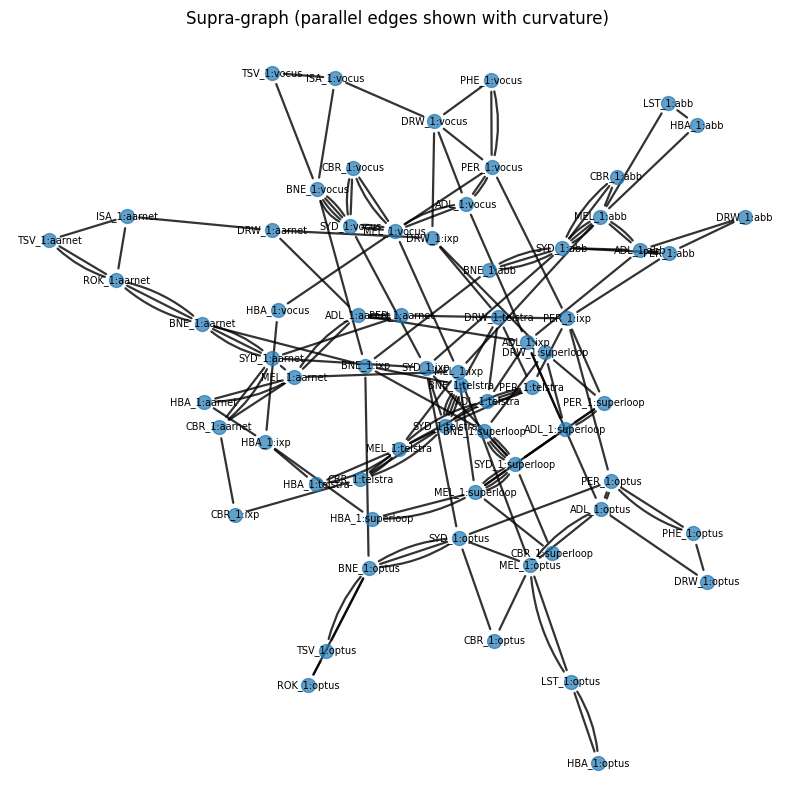

In [2]:
import networkx as nx
import matplotlib.pyplot as plt

# grab the graph object
G = G_full
# create spring layout and figure
pos = nx.spring_layout(G, seed=1)

plt.figure(figsize=(10, 10))
nx.draw_networkx_nodes(G, pos, node_size=100, alpha=0.7)
nx.draw_networkx_labels(G, pos, labels={n: f"{n[0]}:{n[1]}" for n in G.nodes}, font_size=7)

# Draw parallel edges with different curvature
seen = {}  # (u,v) -> how many parallel edges drawn so far

for u, v, k, d in G.edges(keys=True, data=True):
    # undirected key for pair
    pair = (u, v) if u <= v else (v, u)
    i = seen.get(pair, 0)
    seen[pair] = i + 1

    # curvature: 0 for first edge, then increment by 0.15 either side
    if i == 0:
        rad = 0.0
    else:
        step = 0.15 * ((i + 1) // 2)
        rad = step if i % 2 == 1 else -step

    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v)],
        alpha=0.8,
        width=1.6,
        connectionstyle=f"arc3,rad={rad}",
    )

# create plot
plt.title("Supra-graph (parallel edges shown with curvature)")
plt.axis("off")
plt.show()


## Clustered graph
### Cluster by ISP
#### Old Code

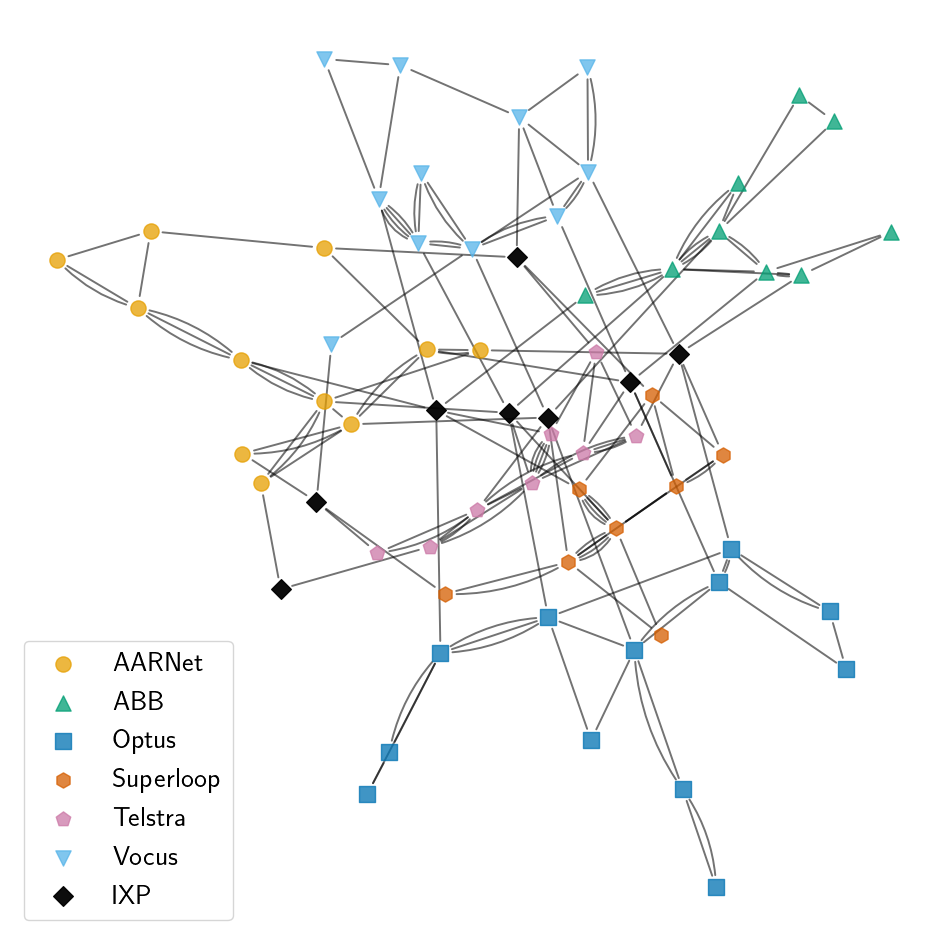

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

# font sizes
plt.rcParams.update({
    "font.size": 20,        # base size
    # "axes.titlesize": 18,
    # "axes.labelsize": 20,
    # "xtick.labelsize": 16,
    # "ytick.labelsize": 16,
    "legend.fontsize": 20,
    "text.usetex": True,
    "font.family": "sans-serif",
    # "font.serif": ["Computer Modern Roman"],
})

# grab the graph again
G = G_full

# function: check for IXP nodes (if has ixp label)
def is_ixp_node(n, data):
    # Prefer explicit metadata if present
    layer = str(data.get("layer","")).lower()
    if "ixp" in layer:
        return True
    return False

# function: check if isp layer and get specific isp
def node_isp(n, data):
    # Prefer metadata
    isp = data.get("isp")
    if isp:
        return str(isp).lower()
    return None

# function: create clustered layout (old function)
def clustered_layout_with_ixp_center(G, seed=1,
                                     isp_spacing=0.2,   # distance between ISP clusters
                                     ixp_scale=1.0,
                                     isp_scale=10):
    # split nodes
    ixp_nodes = [n for n, d in G.nodes(data=True) if is_ixp_node(n, d)]
    isp_nodes = {isp: [] for isp in ISP_LIST}

    # iterate through and put into specific isp lists
    for n, d in G.nodes(data=True):
        isp = node_isp(n, d)
        if isp in ISP_LIST:
            isp_nodes[isp].append(n)

    # 1. centre IXP nodes in the middle
    if ixp_nodes:
        H_ixp = G.subgraph(ixp_nodes).copy()
        pos_ixp = nx.spring_layout(H_ixp, seed=seed)
        # scale
        pos_ixp = {n: (ixp_scale * p[0], ixp_scale * p[1]) for n, p in pos_ixp.items()}
    else:
        pos_ixp = {}

    # 2. cluster each ISP separately around the IXPs
    centers = {
        "aarnet": (-isp_spacing,  isp_spacing),
        "abb": (0, isp_spacing), 
        "optus": ( isp_spacing,  isp_spacing),
        "superloop": ( isp_spacing, -isp_spacing),
        "telstra": (0, -isp_spacing),
        "vocus": (-isp_spacing, -isp_spacing),
    }

    pos = {}
    pos.update(pos_ixp)

    # go through nodes and put into their position
    for isp, nodes in isp_nodes.items():
        if not nodes:
            continue

        H = G.subgraph(nodes).copy()

        # create spring layout
        p = nx.spring_layout(H, seed=seed)

        # scale and shift to its cluster center
        cx, cy = centers.get(isp, (0, 0))
        for n, (x, y) in p.items():
            pos[n] = (isp_scale * x + cx, isp_scale * y + cy)

    # 3. remaining nodes put near center
    remaining = [n for n in G.nodes if n not in pos]
    if remaining:
        H_rem = G.subgraph(remaining).copy()
        p_rem = nx.spring_layout(H_rem, seed=seed)
        # tuck them near middle (small scale)
        for n, (x, y) in p_rem.items():
            pos[n] = (0.6 * x, 0.6 * y)

    return pos

### old plot functions ###
plt.figure(figsize=(12, 12))

# draw graph
## first ISP nodes
for isp in ISP_LIST:
    nodelist = [n for n, d in G.nodes(data=True) if node_isp(n, d) == isp]
    if not nodelist:
        continue
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=nodelist,
        node_size=120,
        alpha=0.75,
        node_color=ISP_COLOURS.get(isp, "gray"),
        node_shape=ISP_STYLES[isp],
        label=ISP_LABELS[isp]
    )

## then IXP nodes
ixp_nodes = [n for n, d in G.nodes(data=True) if is_ixp_node(n, d)]
if ixp_nodes:
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=ixp_nodes,
        node_size=100,
        alpha=0.95,
        node_color="black",
        node_shape="D",
        label="IXP"
    )

## add labels
# nx.draw_networkx_labels(
#     G, pos,
#     labels={n: f"{n[0]}:{n[1]}" if isinstance(n, tuple) and len(n) >= 2 else str(n) for n in G.nodes},
#     font_size=7
# )

## add curvature where necessary for overlapping edges
seen = defaultdict(int)
for u, v, k, d in G.edges(keys=True, data=True):
    pair = (u, v) if str(u) <= str(v) else (v, u)
    i = seen[pair]
    seen[pair] += 1

    rad = 0.0 if i == 0 else (0.15 * ((i + 1) // 2)) * (1 if i % 2 == 1 else -1)

    nx.draw_networkx_edges(
        G, pos,
        edgelist=[(u, v)],
        alpha=0.55,
        width=1.4,
        connectionstyle=f"arc3,rad={rad}",
    )

# plot
# plt.title("Clustered supra-graph: ISP clusters around central IXPs")
plt.legend()
plt.axis("off")
plt.savefig("images/model_hub_spoke.pdf", bbox_inches='tight', transparent=True)
plt.show()


#### New plot of all layers

C:\Users\benja\AppData\Local\Temp\ipykernel_14628\2368478072.py:58: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lon, lat = float(lon), float(lat)


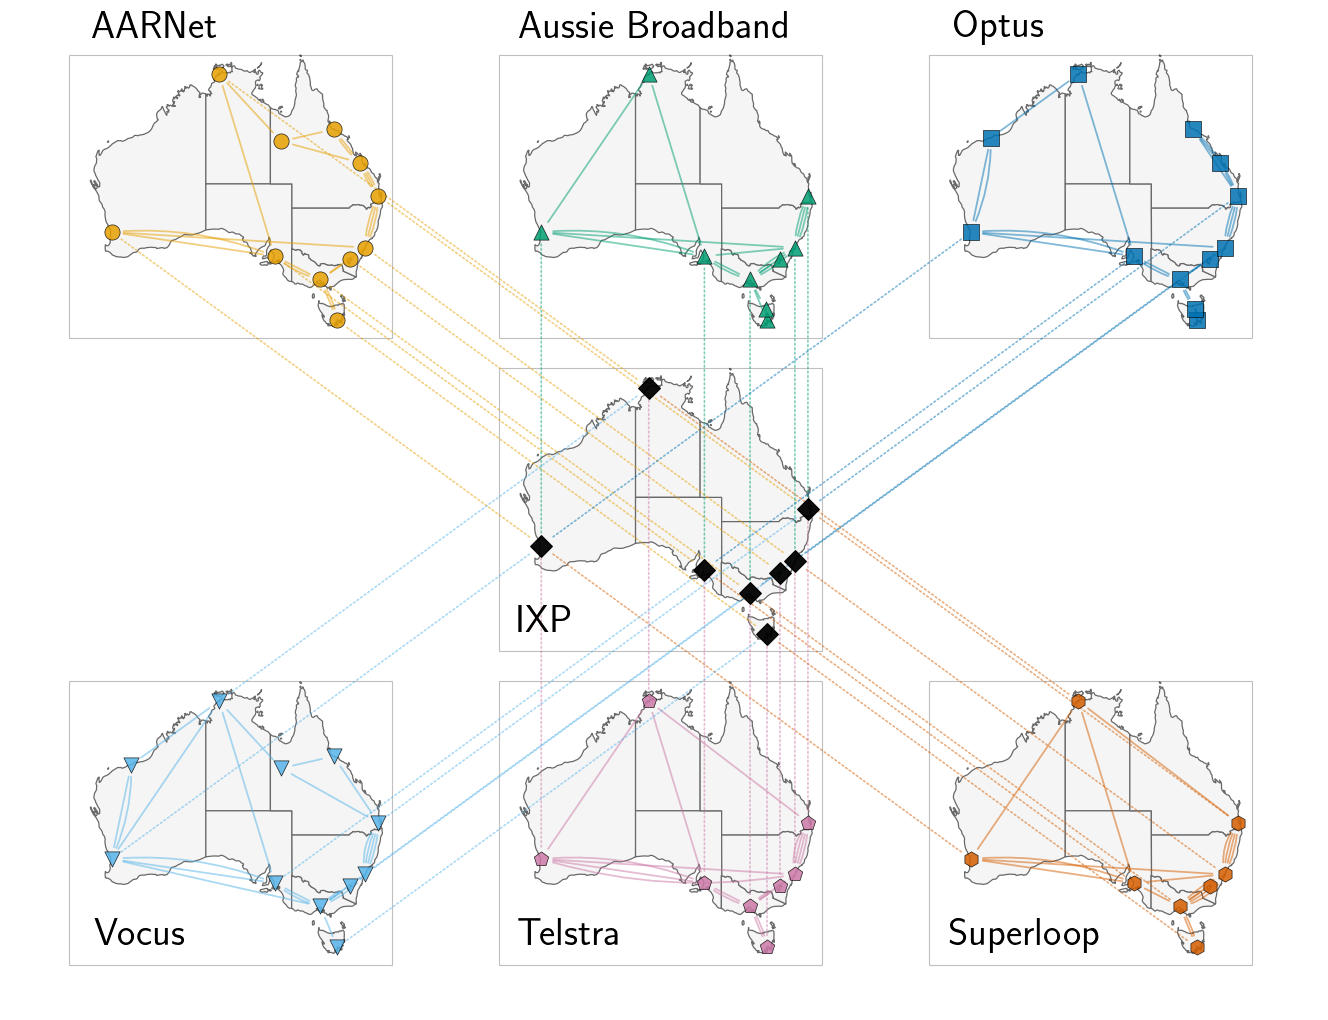

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
from shapely import affinity
import math
import os
import geopandas as gpd

# font sizes
plt.rcParams.update({
    "font.size": 20,        # base size
    # "axes.titlesize": 18,
    # "axes.labelsize": 20,
    # "xtick.labelsize": 16,
    # "ytick.labelsize": 16,
    "legend.fontsize": 30,
    "text.usetex": True,
    "font.family": "sans-serif",
    # "font.serif": ["Computer Modern Roman"],
})

# come up with parameters to bound the map of Aus for each layer
# approximate Australia bounding box
AUS_LON_MIN, AUS_LON_MAX = 110, 155
AUS_LAT_MIN, AUS_LAT_MAX = -45, -10

AUS_LON0 = (AUS_LON_MIN + AUS_LON_MAX) / 2
AUS_LAT0 = (AUS_LAT_MIN + AUS_LAT_MAX) / 2

# longitude correction so Australia does not look too stretched
LON_CORRECTION = math.cos(math.radians(AUS_LAT0))

# grab location for AUS state outline
NE_ADMIN1_POLY_ZIP = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces.zip"
NE_ADMIN1_POLY_LOCAL = "ne_50m_admin_1_states_provinces.zip"

# function: load AUS state outline
def load_au_state_polygons():
    if not os.path.exists(NE_ADMIN1_POLY_LOCAL):
        print("Downloading Natural Earth admin-1 state polygons...")
        urllib.request.urlretrieve(NE_ADMIN1_POLY_ZIP, NE_ADMIN1_POLY_LOCAL)

    gdf = gpd.read_file(f"zip://{os.path.abspath(NE_ADMIN1_POLY_LOCAL)}").to_crs("EPSG:4326")

    if "adm0_a3" in gdf.columns:
        gdf = gdf[gdf["adm0_a3"].astype(str).str.upper() == "AUS"]
    elif "admin" in gdf.columns:
        gdf = gdf[gdf["admin"].astype(str).str.lower() == "australia"]
    elif "ADMIN" in gdf.columns:
        gdf = gdf[gdf["ADMIN"].astype(str).str.lower() == "australia"]

    return gdf

# need function to get the lon/lat coordinates for specific node
def get_lon_lat(n, d):
    lon, lat = d.get("lon"), d.get("lat")
    try:
        lon, lat = float(lon), float(lat)
    except (TypeError, ValueError):
        return None
    return lon, lat

# function to scale coordinates
def geo_to_panel_xy(lon, lat, center, scale=0.16):
    cx, cy = center
    x = (lon - AUS_LON0) * LON_CORRECTION
    y = lat - AUS_LAT0
    return cx + scale * x, cy + scale * y

# function to determine layer (and standardise in case)
def node_layer(n, data):
    if is_ixp_node(n, data):
        return "ixp"
    isp = node_isp(n, data)
    if isp in ISP_LIST:
        return isp
    return None

# function to add in the AUS maps
def transform_au_polygons_to_panel(au_states, center, scale=0.16):
    cx, cy = center

    sx = scale * LON_CORRECTION
    sy = scale

    transformed = au_states.copy()

    transformed["geometry"] = transformed["geometry"].apply(
        lambda geom: affinity.translate(
            affinity.scale(
                geom,
                xfact=sx,
                yfact=sy,
                origin=(AUS_LON0, AUS_LAT0),
            ),
            xoff=cx - AUS_LON0,
            yoff=cy - AUS_LAT0,
        )
    )

    return transformed

# grab the graph again
G = G_full

# function: check for IXP nodes (if has ixp label)
def is_ixp_node(n, data):
    # Prefer explicit metadata if present
    layer = str(data.get("layer","")).lower()
    if "ixp" in layer:
        return True
    return False

# function: check if isp layer and get specific isp
def node_isp(n, data):
    # Prefer metadata
    isp = data.get("isp")
    if isp:
        return str(isp).lower()
    return None

# new function: to get layout of nodes
def multilayer_geo_layout(
    G,
    scale=0.16,
    panel_dx=8.5,
    panel_dy=6.2,
    seed=1,
):
    """
    create layout with each ISP drawn correctly relative to Aus. Put in separate panels.
    """

    layer_centers = {
        "aarnet":    (-panel_dx,  panel_dy),
        "abb":       (0.0,        panel_dy),
        "optus":     (panel_dx,   panel_dy),

        "ixp":       (0.0,        0.0),

        "vocus":     (-panel_dx, -panel_dy),
        "telstra":   (0.0,       -panel_dy),
        "superloop": (panel_dx,  -panel_dy),
    }

    pos = {}

    # First place nodes using real geographic coordinates
    for n, data in G.nodes(data=True):
        layer = node_layer(n, data)

        if layer not in layer_centers:
            continue

        lonlat = get_lon_lat(n, data)

        if lonlat is None:
            continue

        lon, lat = lonlat
        pos[n] = geo_to_panel_xy(
            lon,
            lat,
            center=layer_centers[layer],
            scale=scale,
        )

    # Fallback for nodes without coordinates
    # These are placed near their layer centre using a small spring layout.
    missing_by_layer = defaultdict(list)

    for n, data in G.nodes(data=True):
        if n in pos:
            continue

        layer = node_layer(n, data)

        if layer in layer_centers:
            missing_by_layer[layer].append(n)

    for layer, nodes in missing_by_layer.items():
        if not nodes:
            continue

        H = G.subgraph(nodes).copy()
        p = nx.spring_layout(H, seed=seed)

        cx, cy = layer_centers[layer]

        for n, xy in p.items():
            x, y = xy
            pos[n] = (cx + 0.6 * x, cy + 0.6 * y)

    return pos, layer_centers

# use positioning function to create graph
# pos = clustered_layout_with_ixp_center(G, seed=1, isp_spacing=6.0, ixp_scale=1.2, isp_scale=1.4)
pos, layer_centers = multilayer_geo_layout(
    G,
    scale=0.16,
    panel_dx=8.5,
    panel_dy=6.2,
    seed=1,
)

# NEW PLOTTING CODE
au_states = load_au_state_polygons()

fig, ax = plt.subplots(figsize=(18, 13))

# helper function: edge iterator
def edge_iter(G):
    if G.is_multigraph():
        yield from G.edges(keys=True, data=True)
    else:
        for u, v, d in G.edges(data=True):
            yield u, v, None, d


# helper function: find node layer
def get_existing_node_layer(n):
    return node_layer(n, G.nodes[n])

# draw AUS maps
layers_to_draw = ["aarnet", "abb", "optus", "ixp", "vocus", "telstra", "superloop"]

for layer in layers_to_draw:
    if layer not in layer_centers:
        continue

    au_panel = transform_au_polygons_to_panel(
        au_states,
        center=layer_centers[layer],
        scale=0.16,   # should match the scale used in multilayer_geo_layout
    )

    au_panel.plot(
        ax=ax,
        color="whitesmoke",
        edgecolor="dimgray",
        linewidth=0.9,
        zorder=0,
    )


# create a map box for each layer
panel_labels = {
    "aarnet": "AARNet",
    "abb": "Aussie Broadband",
    "optus": "Optus",
    "ixp": "IXP",
    "vocus": "Vocus",
    "telstra": "Telstra",
    "superloop": "Superloop",
}

# scale to match Aus map approximately
map_width = scale_width = 0.16 * (AUS_LON_MAX - AUS_LON_MIN) * LON_CORRECTION
map_height = scale_height = 0.16 * (AUS_LAT_MAX - AUS_LAT_MIN)

# go through each layer and add centre
for layer, (cx, cy) in layer_centers.items():
    if panel_labels.get(layer, layer.upper()) in ['Aussie Broadband']:
        l_cx = cx - 0.1
        l_cy = cy + map_height / 2 + 0.2
    elif panel_labels.get(layer, layer.upper()) in ['Optus']:
        l_cx = cx - 1.8
        l_cy = cy + map_height / 2 + 0.2
    elif panel_labels.get(layer, layer.upper()) in ['AARNet']:
        l_cx = cx - 1.5
        l_cy = cy + map_height / 2 + 0.2
    elif panel_labels.get(layer, layer.upper()) in ['IXP']:
        l_cx = cx - 2.25
        l_cy = cy + map_height / 2 - 5.35
    elif panel_labels.get(layer, layer.upper()) in ['Superloop']:
        l_cx = cx - 1.3
        l_cy = cy + map_height / 2 - 5.35
    elif panel_labels.get(layer, layer.upper()) in ['Vocus', 'Telstra']:
        l_cx = cx - 1.8
        l_cy = cy + map_height / 2 - 5.35

    ax.text(
        l_cx,
        l_cy,
        panel_labels.get(layer, layer.upper()),
        ha="center",
        va="bottom",
        fontsize=28,
        fontweight="bold",
    )

    # Optional faint bounding box for each mini-map
    rect = plt.Rectangle(
        (cx - map_width / 2, cy - map_height / 2),
        map_width,
        map_height,
        fill=False,
        linewidth=0.8,
        alpha=0.25,
        linestyle="-",
    )
    ax.add_patch(rect)


# split into inter and intra layer edges
intra_edges = []
inter_edges = []

for u, v, k, d in edge_iter(G):
    lu = get_existing_node_layer(u)
    lv = get_existing_node_layer(v)

    if lu == lv:
        intra_edges.append((u, v, k, d))
    else:
        inter_edges.append((u, v, k, d))


# draw intra-layer edges
seen = defaultdict(int)

for u, v, k, d in intra_edges:
    pair = tuple(sorted((str(u), str(v))))
    i = seen[pair]
    seen[pair] += 1

    rad = 0.0 if i == 0 else (0.12 * ((i + 1) // 2)) * (1 if i % 2 == 1 else -1)

    lu = get_existing_node_layer(u)

    edge_colour = ISP_COLOURS.get(lu, "gray")

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v)],
        ax=ax,
        edge_color=edge_colour,
        alpha=0.5,
        width=1.3,
        connectionstyle=f"arc3,rad={rad}",
    )


# draw inter-layer edges
seen = defaultdict(int)

for u, v, k, d in inter_edges:
    pair = tuple(sorted((str(u), str(v))))
    i = seen[pair]
    seen[pair] += 1

    rad = 0.0 if i == 0 else (0.10 * ((i + 1) // 2)) * (1 if i % 2 == 1 else -1)

    lu = get_existing_node_layer(u)

    edge_colour = ISP_COLOURS.get(lu, "gray")

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v)],
        ax=ax,
        edge_color=edge_colour,
        alpha=0.5,
        width=1.2,
        style=":",
        connectionstyle=f"arc3,rad={rad}",
    )


# draw ISP nodes
for isp in ISP_LIST:
    nodelist = [
        n for n, d in G.nodes(data=True)
        if node_isp(n, d) == isp
    ]
    if not nodelist:
        continue
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=nodelist,
        ax=ax,
        node_size=120,
        alpha=0.85,
        node_color=ISP_COLOURS.get(isp, "gray"),
        node_shape=ISP_STYLES[isp],
        label=ISP_LABELS[isp],
        linewidths=0.5,
        edgecolors="black",
    )

# draw IXP nodes
ixp_nodes = [
    n for n, d in G.nodes(data=True)
    if is_ixp_node(n, d)
]
if ixp_nodes:
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=ixp_nodes,
        ax=ax,
        node_size=120,
        alpha=0.95,
        node_color="black",
        node_shape="D",
        label="IXP",
    )


# final formatting
ax.set_aspect("equal")
ax.axis("off")

# ax.legend(
#     loc="lower center",
#     # bbox_to_anchor=(0.5, -0.06),
#     bbox_to_anchor=(0.5, -0.12),
#     ncol=4,
#     frameon=False,
# )

plt.savefig(
    "images/model_multilayer_geo_panels.pdf",
    bbox_inches="tight",
    transparent=True,
)
plt.savefig(
    "images/model_multilayer_geo_panels.svg",
    bbox_inches="tight",
    transparent=True,
)

plt.show()

#### New version with IXPs in ring instead

C:\Users\benja\AppData\Local\Temp\ipykernel_14628\786979736.py:59: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  lon, lat = float(lon), float(lat)


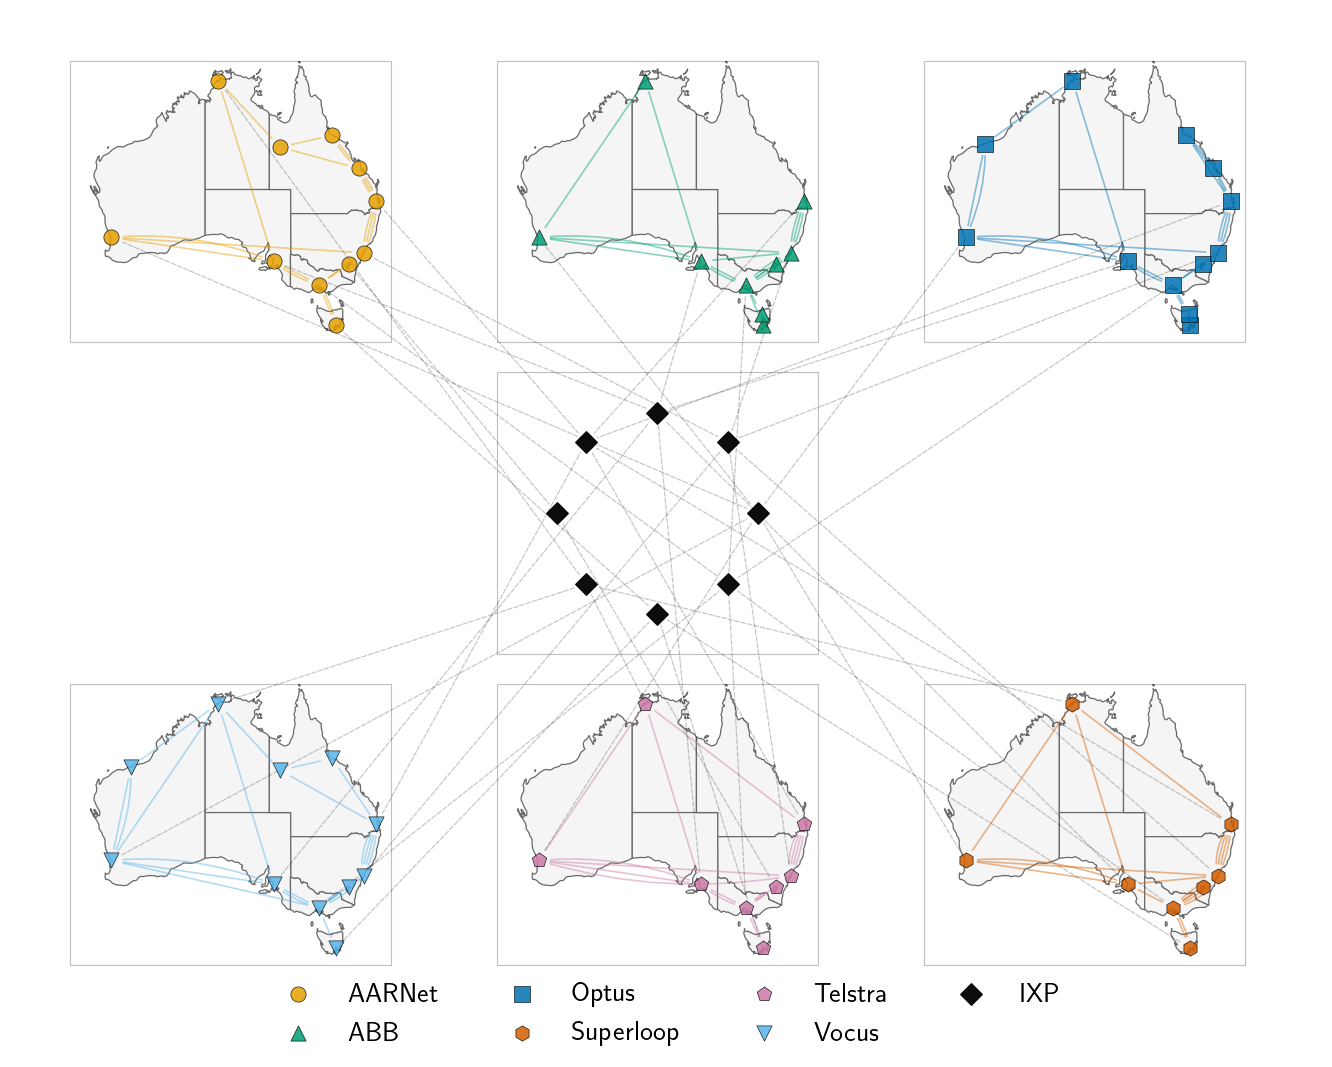

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
from shapely import affinity
import math
import os
import geopandas as gpd
import numpy as np

# font sizes
plt.rcParams.update({
    "font.size": 20,        # base size
    # "axes.titlesize": 18,
    # "axes.labelsize": 20,
    # "xtick.labelsize": 16,
    # "ytick.labelsize": 16,
    "legend.fontsize": 20,
    "text.usetex": True,
    "font.family": "sans-serif",
    # "font.serif": ["Computer Modern Roman"],
})

# come up with parameters to bound the map of Aus for each layer
# approximate Australia bounding box
AUS_LON_MIN, AUS_LON_MAX = 110, 155
AUS_LAT_MIN, AUS_LAT_MAX = -45, -10

AUS_LON0 = (AUS_LON_MIN + AUS_LON_MAX) / 2
AUS_LAT0 = (AUS_LAT_MIN + AUS_LAT_MAX) / 2

# longitude correction so Australia does not look too stretched
LON_CORRECTION = math.cos(math.radians(AUS_LAT0))

# grab location for AUS state outline
NE_ADMIN1_POLY_ZIP = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces.zip"
NE_ADMIN1_POLY_LOCAL = "ne_50m_admin_1_states_provinces.zip"

# function: load AUS state outline
def load_au_state_polygons():
    if not os.path.exists(NE_ADMIN1_POLY_LOCAL):
        print("Downloading Natural Earth admin-1 state polygons...")
        urllib.request.urlretrieve(NE_ADMIN1_POLY_ZIP, NE_ADMIN1_POLY_LOCAL)

    gdf = gpd.read_file(f"zip://{os.path.abspath(NE_ADMIN1_POLY_LOCAL)}").to_crs("EPSG:4326")

    if "adm0_a3" in gdf.columns:
        gdf = gdf[gdf["adm0_a3"].astype(str).str.upper() == "AUS"]
    elif "admin" in gdf.columns:
        gdf = gdf[gdf["admin"].astype(str).str.lower() == "australia"]
    elif "ADMIN" in gdf.columns:
        gdf = gdf[gdf["ADMIN"].astype(str).str.lower() == "australia"]

    return gdf

# need function to get the lon/lat coordinates for specific node
def get_lon_lat(n, d):
    lon, lat = d.get("lon"), d.get("lat")
    try:
        lon, lat = float(lon), float(lat)
    except (TypeError, ValueError):
        return None
    return lon, lat

# function to scale coordinates
def geo_to_panel_xy(lon, lat, center, scale=0.16):
    cx, cy = center
    x = (lon - AUS_LON0) * LON_CORRECTION
    y = lat - AUS_LAT0
    return cx + scale * x, cy + scale * y

# function to determine layer (and standardise in case)
def node_layer(n, data):
    if is_ixp_node(n, data):
        return "ixp"
    isp = node_isp(n, data)
    if isp in ISP_LIST:
        return isp
    return None

# function to add in the AUS maps
def transform_au_polygons_to_panel(au_states, center, scale=0.16):
    cx, cy = center

    sx = scale * LON_CORRECTION
    sy = scale

    transformed = au_states.copy()

    transformed["geometry"] = transformed["geometry"].apply(
        lambda geom: affinity.translate(
            affinity.scale(
                geom,
                xfact=sx,
                yfact=sy,
                origin=(AUS_LON0, AUS_LAT0),
            ),
            xoff=cx - AUS_LON0,
            yoff=cy - AUS_LAT0,
        )
    )

    return transformed

# grab the graph again
G = G_full

# function: check for IXP nodes (if has ixp label)
def is_ixp_node(n, data):
    # Prefer explicit metadata if present
    layer = str(data.get("layer","")).lower()
    if "ixp" in layer:
        return True
    return False

# function: check if isp layer and get specific isp
def node_isp(n, data):
    # Prefer metadata
    isp = data.get("isp")
    if isp:
        return str(isp).lower()
    return None

# new function: to get layout of nodes
def multilayer_geo_layout(
    G,
    scale=0.16,
    panel_dx=8.5,
    panel_dy=6.2,
    seed=1,
    ixp_ring_radius=1.2,
    ixp_start_angle=np.pi / 2,
):
    """
    Create layout with each ISP drawn correctly relative to Aus.
    IXP nodes are placed in a central ring rather than in geographic layout.
    """

    layer_centers = {
        "aarnet":    (-panel_dx,  panel_dy),
        "abb":       (0.0,        panel_dy),
        "optus":     (panel_dx,   panel_dy),

        "ixp":       (0.0,        0.0),

        "vocus":     (-panel_dx, -panel_dy),
        "telstra":   (0.0,       -panel_dy),
        "superloop": (panel_dx,  -panel_dy),
    }

    pos = {}

    # ------------------------------------------------------------
    # 1. Place ISP nodes using real geographic coordinates
    # ------------------------------------------------------------
    for n, data in G.nodes(data=True):
        layer = node_layer(n, data)

        # Important: skip IXP here.
        # IXP nodes will be placed in a ring instead.
        if layer == "ixp":
            continue

        if layer not in layer_centers:
            continue

        lonlat = get_lon_lat(n, data)

        if lonlat is None:
            continue

        lon, lat = lonlat

        pos[n] = geo_to_panel_xy(
            lon,
            lat,
            center=layer_centers[layer],
            scale=scale,
        )

    # ------------------------------------------------------------
    # 2. Place IXP nodes in a central ring
    # ------------------------------------------------------------
    ixp_nodes = [
        n for n, d in G.nodes(data=True)
        if is_ixp_node(n, d)
    ]

    ixp_nodes = sorted(ixp_nodes, key=str)

    cx, cy = layer_centers["ixp"]

    if len(ixp_nodes) == 1:
        pos[ixp_nodes[0]] = (cx, cy)

    elif len(ixp_nodes) > 1:
        for i, n in enumerate(ixp_nodes):
            theta = ixp_start_angle + 2 * np.pi * i / len(ixp_nodes)

            x = cx + ixp_ring_radius * np.cos(theta)
            y = cy + ixp_ring_radius * np.sin(theta)

            pos[n] = (x, y)

    # ------------------------------------------------------------
    # 3. Fallback for non-IXP nodes without coordinates
    # ------------------------------------------------------------
    missing_by_layer = defaultdict(list)

    for n, data in G.nodes(data=True):
        if n in pos:
            continue

        layer = node_layer(n, data)

        # IXP nodes should already have been placed above.
        if layer == "ixp":
            continue

        if layer in layer_centers:
            missing_by_layer[layer].append(n)

    for layer, nodes in missing_by_layer.items():
        if not nodes:
            continue

        H = G.subgraph(nodes).copy()
        p = nx.spring_layout(H, seed=seed)

        cx, cy = layer_centers[layer]

        for n, xy in p.items():
            x, y = xy
            pos[n] = (cx + 0.6 * x, cy + 0.6 * y)

    return pos, layer_centers

# use positioning function to create graph
# pos = clustered_layout_with_ixp_center(G, seed=1, isp_spacing=6.0, ixp_scale=1.2, isp_scale=1.4)
MAP_SCALE = 0.16

pos, layer_centers = multilayer_geo_layout(
    G,
    scale=MAP_SCALE,
    panel_dx=8.5,
    panel_dy=6.2,
    seed=1,
    ixp_ring_radius=2.0,
)

# NEW PLOTTING CODE
au_states = load_au_state_polygons()

fig, ax = plt.subplots(figsize=(18, 13))

# helper function: edge iterator
def edge_iter(G):
    if G.is_multigraph():
        yield from G.edges(keys=True, data=True)
    else:
        for u, v, d in G.edges(data=True):
            yield u, v, None, d


# helper function: find node layer
def get_existing_node_layer(n):
    return node_layer(n, G.nodes[n])

# draw AUS maps
layers_to_draw = ["aarnet", "abb", "optus", "vocus", "telstra", "superloop"]

for layer in layers_to_draw:
    if layer not in layer_centers:
        continue

    au_panel = transform_au_polygons_to_panel(
        au_states,
        center=layer_centers[layer],
        scale=0.16,   # should match the scale used in multilayer_geo_layout
    )

    au_panel.plot(
        ax=ax,
        color="whitesmoke",
        edgecolor="dimgray",
        linewidth=0.9,
        zorder=0,
    )


# create a map box for each layer
panel_labels = {
    "aarnet": "AARNet",
    "abb": "Aussie Broadband",
    "optus": "Optus",
    "ixp": "IXP / Interconnection",
    "vocus": "Vocus",
    "telstra": "Telstra",
    "superloop": "Superloop",
}

# scale to match Aus map approximately
map_width = scale_width = 0.16 * (AUS_LON_MAX - AUS_LON_MIN) * LON_CORRECTION
map_height = scale_height = 0.16 * (AUS_LAT_MAX - AUS_LAT_MIN)

# go through each layer and add centre
for layer, (cx, cy) in layer_centers.items():

    # Skip rectangular Australia-style box for IXP layer
    # if layer == "ixp":
    #     continue

    rect = plt.Rectangle(
        (cx - map_width / 2, cy - map_height / 2),
        map_width,
        map_height,
        fill=False,
        linewidth=0.8,
        alpha=0.25,
        linestyle="-",
    )

    ax.add_patch(rect)


# split into inter and intra layer edges
intra_edges = []
inter_edges = []

for u, v, k, d in edge_iter(G):
    lu = get_existing_node_layer(u)
    lv = get_existing_node_layer(v)

    if lu == lv:
        intra_edges.append((u, v, k, d))
    else:
        inter_edges.append((u, v, k, d))


# draw intra-layer edges
seen = defaultdict(int)

for u, v, k, d in intra_edges:
    pair = tuple(sorted((str(u), str(v))))
    i = seen[pair]
    seen[pair] += 1

    rad = 0.0 if i == 0 else (0.12 * ((i + 1) // 2)) * (1 if i % 2 == 1 else -1)

    lu = get_existing_node_layer(u)

    edge_colour = ISP_COLOURS.get(lu, "gray")

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v)],
        ax=ax,
        edge_color=edge_colour,
        alpha=0.45,
        width=1.2,
        connectionstyle=f"arc3,rad={rad}",
    )


# draw inter-layer edges
seen = defaultdict(int)

for u, v, k, d in inter_edges:
    pair = tuple(sorted((str(u), str(v))))
    i = seen[pair]
    seen[pair] += 1

    rad = 0.0 if i == 0 else (0.10 * ((i + 1) // 2)) * (1 if i % 2 == 1 else -1)

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v)],
        ax=ax,
        edge_color="black",
        alpha=0.22,
        width=0.9,
        style="--",
        connectionstyle=f"arc3,rad={rad}",
    )


# draw ISP nodes
for isp in ISP_LIST:
    nodelist = [
        n for n, d in G.nodes(data=True)
        if node_isp(n, d) == isp
    ]
    if not nodelist:
        continue
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=nodelist,
        ax=ax,
        node_size=120,
        alpha=0.85,
        node_color=ISP_COLOURS.get(isp, "gray"),
        node_shape=ISP_STYLES[isp],
        label=ISP_LABELS[isp],
        linewidths=0.5,
        edgecolors="black",
    )

# draw IXP nodes
ixp_nodes = [
    n for n, d in G.nodes(data=True)
    if is_ixp_node(n, d)
]
if ixp_nodes:
    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=ixp_nodes,
        ax=ax,
        node_size=120,
        alpha=0.95,
        node_color="black",
        node_shape="D",
        label="IXP",
    )


# final formatting
ax.set_aspect("equal")
ax.axis("off")

ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.06),
    ncol=4,
    frameon=False,
)

plt.savefig(
    "images/model_multilayer_geo_panels_ixp_circle.pdf",
    bbox_inches="tight",
    transparent=True,
)
plt.savefig(
    "images/model_multilayer_geo_panels_ixp_circle.svg",
    bbox_inches="tight",
    transparent=True,
)

plt.show()

## Identify SRG groups

In [6]:
import pandas as pd
import networkx as nx
import numpy as np
from collections import defaultdict
import itertools
import re

# helper functions
## function: lowering and stripping string
def norm(s):
    return str(s).strip().lower()

## checking if is an isp node
def is_isp_node(n, d, isp):
    if norm(d.get("isp","")) == norm(isp):
        return True
    return False

## checking if is an ixp node
def is_ixp_node(n, d):
    layer = norm(d.get("layer",""))
    if "ixp" in layer:
        return True
    return False

# srg edge grouping functions
## function: add to the srg df a list of tuples corresponding to the edges within that srg
### initialise srg_df
def new_srg_df(og_df):
    srg_df = og_df.copy()
    srg_df.rename(columns={"start": "u", "end": "v"}, inplace=True)
    srg_df['edges'] = [[] for _ in range(len(srg_df))]
    return srg_df

### assign the edges to the corresponding srgs
def srg_link_grouping(srg_df, srgs, u, v, k, isp):
    for srg in srgs.split(', '):
        srg_l = srg_df.loc[srg_df['srg_id'] == srg.strip(), 'edges'].iloc[0]
        srg_l.append((k, u, v, isp))
        srg_df.loc[srg_df['srg_id'] == srg.strip(), 'edges'].iloc[0] = srg_l
    return srg_df

### main
def fill_srg_list(edge_df, srg_og_df):
    # create list of the desired columns
    link_k = list(edge_df['link_id'])
    link_u = list(edge_df['u'])
    link_v = list(edge_df['v'])
    link_isp = list(edge_df['isp'])
    srg_cons = list(edge_df['srg_cons'])
    srg_ideal = list(edge_df['srg_ideal'])

    # initialise new dfs
    srg_c_df = new_srg_df(srg_og_df)
    srg_i_df = new_srg_df(srg_og_df)

    # run key functions
    for i in range(len(edge_df)):
        srg_c_df = srg_link_grouping(srg_c_df, srg_cons[i], link_u[i], link_v[i], link_k[i], link_isp[i])
        srg_i_df = srg_link_grouping(srg_i_df, srg_ideal[i], link_u[i], link_v[i], link_k[i], link_isp[i])

    # REMOVE ROWS WITH NO ASSOCIATED EDGES
    srg_c_df = srg_c_df[srg_c_df['edges'].map(len) > 0]
    srg_i_df = srg_i_df[srg_i_df['edges'].map(len) > 0]

    return srg_c_df, srg_i_df

# run main function to get new srgs
srg_c_df, srg_i_df = fill_srg_list(edge_df, srg_city_df)

C:\Users\benja\AppData\Local\Temp\ipykernel_14628\1439967591.py:40: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  srg_df.loc[srg_df['srg_id'] == srg.strip(), 'edges'].iloc[0] = srg_l


## Create SRG map
### Create SRG graph object

In [7]:
# function: build srg graph
def build_srg_graph(srg_df: pd.DataFrame,
                    sites_df: pd.DataFrame) -> nx.MultiGraph:
    # create the multigraph
    G = nx.MultiGraph()
    
    # add site nodes
    for _, site_row in sites_df.iterrows():
        G.add_node(
            site_row['site_id'],
            layer=f"srg",
            site_id=site_row['site_id'],
            lat=site_row["lat"],
            lon=site_row["lon"],
            city=site_row["city"],
            kind=site_row["kind"],
            population=site_row["population"],
        )
    
    # add edges along with attributes (edge metadata)
    for _, row in srg_df.iterrows():
        u = row["u"]
        v = row["v"]
        # check for any unwanted edges
        if u not in G.nodes or v not in G.nodes:
            continue
        key = row['srg_id']
        attrs = row.drop(labels=["srg_id","u","v"]).to_dict()
        # Use link_id as the MultiGraph key so parallel edges don't overwrite
        G.add_edge(u, v, key=key, **attrs)

    return G

def build_srg_dif_graph(srg_c_df: pd.DataFrame,srg_i_df: pd.DataFrame,
                    sites_df: pd.DataFrame) -> nx.MultiGraph:
    # create the multigraph
    G = nx.MultiGraph()
    
    # add site nodes
    for _, site_row in sites_df.iterrows():
        G.add_node(
            site_row['site_id'],
            layer=f"srg",
            site_id=site_row['site_id'],
            lat=site_row["lat"],
            lon=site_row["lon"],
            city=site_row["city"],
            kind=site_row["kind"],
            population=site_row["population"],
        )

    # find difference between the lists so that can only add those srgs
    srg_c_list = list(srg_c_df['srg_id'])
    srg_i_list = list(srg_i_df['srg_id'])
    diff = list(set(srg_i_list) - set(srg_c_list))
    
    # add edges along with attributes (edge metadata)
    for _, row in srg_i_df.iterrows():
        u = row["u"]
        v = row["v"]
        # check for any unwanted edges
        if u not in G.nodes or v not in G.nodes:
            continue
        key = row['srg_id']
        # check if key is in the diff list, otherwise continue
        if key not in diff:
            continue
        attrs = row.drop(labels=["srg_id","u","v"]).to_dict()
        # Use link_id as the MultiGraph key so parallel edges don't overwrite
        G.add_edge(u, v, key=key, **attrs)

    return G

# run the function, creating the full network
G_srg_c = build_srg_graph(srg_c_df, site_df)
G_srg_i = build_srg_graph(srg_i_df, site_df)
G_srg_dif = build_srg_dif_graph(srg_c_df, srg_i_df, site_df)

In [8]:
srg_i_df['srg_type'].value_counts()

srg_type
road         24
sub          16
rail_road    15
Name: count, dtype: int64

### Create SRG map


{'ADL_1': 'Adelaide', 'BNE_1': 'Brisbane', 'CBR_1': 'Canberra', 'DRW_1': 'Darwin', 'HBA_1': 'Hobart', 'MEL_1': 'Melbourne', 'PER_1': 'Perth', 'SYD_1': 'Sydney', 'LST_1': 'Launceston', 'PHE_1': 'Port Hedland', 'TSV_1': 'Townsville', 'ROK_1': 'Rockhampton', 'ISA_1': 'Mount Isa', 'HGD_1': 'Hughenden', 'LRE_1': 'Longreach', 'PUG_1': 'Port Augusta'}
{'ADL_1': 'ADL', 'BNE_1': 'BNE', 'CBR_1': 'CBR', 'DRW_1': 'DRW', 'HBA_1': 'HBA', 'MEL_1': 'MEL', 'PER_1': 'PER', 'SYD_1': 'SYD', 'LST_1': 'LST', 'PHE_1': 'PHE', 'TSV_1': 'TSV', 'ROK_1': 'ROK', 'ISA_1': 'ISA', 'HGD_1': 'HGD', 'LRE_1': 'LRE', 'PUG_1': 'PUG'}


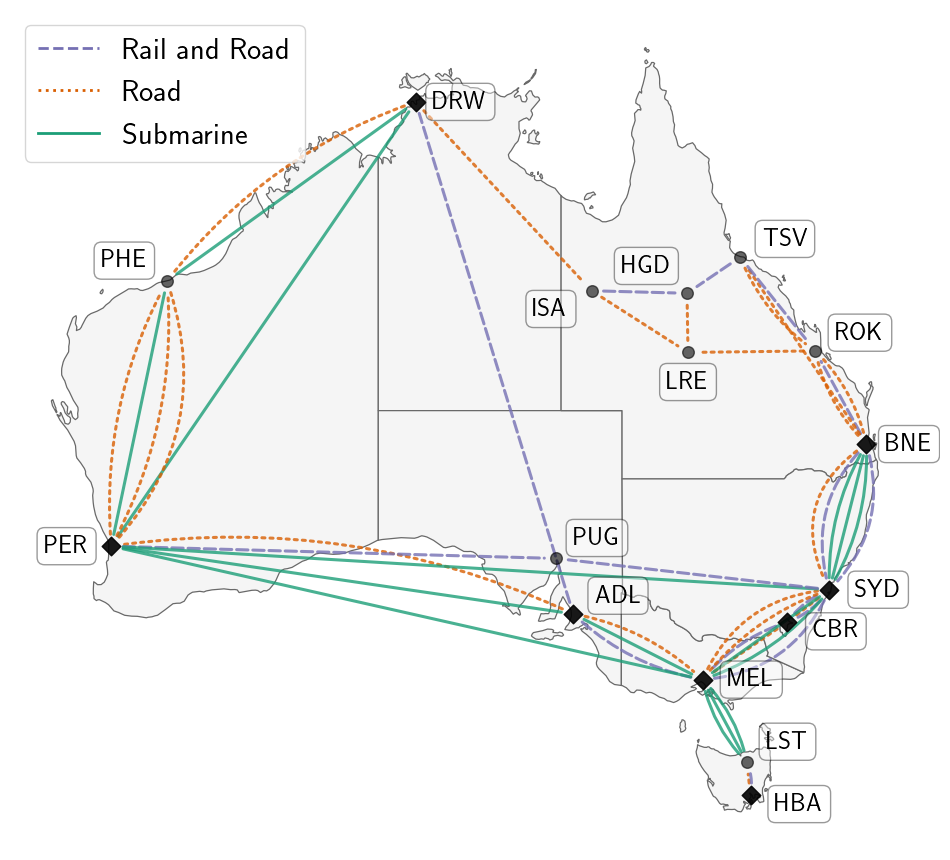

In [9]:
# import packages
import os
import re
import math
import urllib.request
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import defaultdict
from matplotlib.lines import Line2D
from cmap import Colormap
from adjustText import adjust_text

# font sizes
plt.rcParams.update({
    "font.size": 18,        # base size
    # "axes.titlesize": 18,
    # "axes.labelsize": 20,
    # "xtick.labelsize": 16,
    # "ytick.labelsize": 16,
    "legend.fontsize": 22,
    "text.usetex": True,
    "font.family": "sans-serif",
    # "font.serif": ["Computer Modern Roman"],
})

# grab location for AUS state outline
NE_ADMIN1_POLY_ZIP = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces.zip"
NE_ADMIN1_POLY_LOCAL = "ne_50m_admin_1_states_provinces.zip"

POS_ADJUST = {'ADL_1': (2.2,0.8), 'BNE_1': (2.1,0), 'CBR_1': (2.4,-0.4), 'DRW_1': (2.2,0), 'HBA_1': (2.4,-0.4), 'MEL_1': (2.4,0), 'PER_1': (-2.2,0), 'SYD_1': (2.4,0), 'LST_1': (2,0.9), 'PHE_1': (-2.1,0.9), 'TSV_1': (2.2,0.8), 'ROK_1': (2.2,0.8), 'ISA_1': (-2,-0.8), 'HGD_1': (-2,1.2), 'LRE_1': (0,-1.3), 'PUG_1': (2,0.9)}


# function: load AUS state outline
def load_au_state_polygons():
    if not os.path.exists(NE_ADMIN1_POLY_LOCAL):
        print("Downloading Natural Earth admin-1 state polygons...")
        urllib.request.urlretrieve(NE_ADMIN1_POLY_ZIP, NE_ADMIN1_POLY_LOCAL)

    gdf = gpd.read_file(f"zip://{os.path.abspath(NE_ADMIN1_POLY_LOCAL)}").to_crs("EPSG:4326")

    if "adm0_a3" in gdf.columns:
        gdf = gdf[gdf["adm0_a3"].astype(str).str.upper() == "AUS"]
    elif "admin" in gdf.columns:
        gdf = gdf[gdf["admin"].astype(str).str.lower() == "australia"]
    elif "ADMIN" in gdf.columns:
        gdf = gdf[gdf["ADMIN"].astype(str).str.lower() == "australia"]

    return gdf

# function: get lat and lon values
def safe_pos(G):
    pos = {}
    for n, d in G.nodes(data=True):
        lon, lat = d.get("lon"), d.get("lat")
        try:
            lon, lat = float(lon), float(lat)
        except (TypeError, ValueError):
            continue
        if math.isfinite(lon) and math.isfinite(lat):
            pos[n] = (lon, lat)
    return pos

def site_pair(u, v):
    a, b = u[0], v[0]
    return (a, b) if a <= b else (b, a)

# function: remove edges based on filter
def filter_edges(G):
    out = []
    # go through edges and append
    for u, v, k, d in G.edges(keys=True, data=True):
        if d.get("edge_type") in {"attach", "interconnect"}: # SPECIFY FILTER HERE
            continue
        out.append((u, v, k, d))
    return out

# function: create the srg plot
def plot_srg_aus_map(G,filename):
    # load au states
    au_states = load_au_state_polygons()

    # get lat/lon values
    pos = safe_pos(G)

    # grab filtered edges
    edges = [(u, v, k, d) for (u, v, k, d) in filter_edges(G) if u in pos and v in pos]

    labels = nx.get_node_attributes(G, 'city')
    abr_labels = {}
    # create abbreviation labels
    for ke in labels.keys():
        ke_abr = ke[:-2]
        abr_labels[ke] = ke_abr

    print(labels)
    print(abr_labels)

    fig, ax = plt.subplots(figsize=(12, 12))

    # basemap
    au_states.plot(ax=ax, color="whitesmoke", edgecolor="dimgray", linewidth=0.9, zorder=0)

    # nodes - IXPs as diamonds, regional as smaller dots
    # first get two lists of the nodes
    node_types = nx.get_node_attributes(G, 'kind')
    ixp_nodes = [key for key, val in node_types.items() if str(val) == 'MPoP']
    regional_nodes = [key for key, val in node_types.items() if str(val) == 'regional']

    # draw nodes for ixps
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        nodelist=ixp_nodes,
        node_size=90,
        node_color="black",
        node_shape="D",
        alpha=0.9
    )

    # draw nodes for regional
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        nodelist=regional_nodes,
        node_size=70,
        node_color="black",
        alpha=0.6
    )

    label_pos = {n: (pos[n][0] + POS_ADJUST[n][0], pos[n][1] + POS_ADJUST[n][1]) for n in G.nodes}


    nx.draw_networkx_labels(
        G, label_pos, ax=ax,
        labels=abr_labels,
        font_size=18,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.4)
    )

    seen = defaultdict(int)
    for u, v, k, d in edges:
        pair = (u, v) if str(u) <= str(v) else (v, u)
        i = seen[pair]
        seen[pair] += 1

        # calculate curvature: 0 for first edge, then alternate sides with increasing radius
        rad = 0.0 if i == 0 else (0.15 * ((i + 1) // 2)) * (1 if i % 2 == 1 else -1)

        # draw edges differently (if sub, rail, road, rail-road)
        # first determine type
        srg_type = d.get("srg_type")
        edge_style = EDGE_STYLES[srg_type]
        edge_colour = EDGE_COLOURS[srg_type]

        # then draw the edge
        nx.draw_networkx_edges(
            G, pos, ax=ax,
            edgelist=[(u, v)],
            arrows=True,
            connectionstyle=f"arc3,rad={rad}",
            width=2.2,
            alpha=0.8,
            edge_color=edge_colour,
            style=edge_style
        )

    # Create legend entries for each edge type
    legend_lines = [
        Line2D([0], [0], color=EDGE_COLOURS[stype], lw=2, linestyle=EDGE_STYLES[stype], label=EDGE_LABELS[stype])
        for stype in sorted(EDGE_COLOURS.keys()) if stype !='rail' and stype !='mix'
    ]

    ax.legend(handles=legend_lines, loc="upper left")
    x_min, x_max = ax.get_xlim()
    ax.set_xlim(x_min, x_max + 1)
    ax.axis("off")
    plt.savefig(f"images/{filename}_srg_label.pdf", bbox_inches='tight',transparent=True)
    plt.savefig(f"images/{filename}_srg_label.svg", bbox_inches='tight',transparent=True)
    plt.show()


plot_srg_aus_map(G_srg_c,'conservative')
# plot_srg_aus_map(G_srg_dif,'difference')
# plot_srg_aus_map(G_srg_dif,'difference')


# SINGLE EDGE REMOVAL

In [10]:
import pandas as pd
import networkx as nx
import numpy as np
from collections import defaultdict
import itertools
import re

# initial statistics
# number of connected components
# nummber of edges
# largest cc fec
# isolated nodes
# capital pair fractions 
# isp level: doesn't incl ixps
    # edges in ISP layer
    # n components
    # capitals connected number
    # capital pair fractions
    # ave shortest path length
    # diameter
# supra_cap_pair_frac_noixp
# ixp_gain_cap_pair = supra - noixp
# diameter
# ave shortest path length

# inputs
CAPITAL_SITES = ['SYD_1','MEL_1','BNE_1','PER_1','ADL_1','HBA_1','DRW_1','CBR_1']

# helper functions
def norm(s):
    return str(s).strip().lower()

def is_isp_node(n, d, isp):
    if norm(d.get("isp","")) == norm(isp):
        return True
    return False

def is_ixp_node(n, d):
    layer = norm(d.get("layer",""))
    if "ixp" in layer:
        return True
    return False

def capital_node(site_id, isp):
    return (site_id, norm(isp))

# ----------------------------
# SRG mapping: (isp, link_id) -> edges in G_full
# (robustly extracts edge "link id" from attrs or key)
# ----------------------------
_LINK_PAT = re.compile(r"[A-Z]{3}_[A-Z]{3}\d+")

# ----------------------------
# Metric computation (efficient)
# ----------------------------
def components_index(G):
    """
    Returns comp_id dict: node -> component integer
    """
    comp_id = {}
    for i, comp in enumerate(nx.connected_components(G)):
        for n in comp:
            comp_id[n] = i
    return comp_id

def pair_fraction_connected(nodes, comp_id):
    """
    Fraction of unordered pairs in `nodes` that are connected (same component).
    Returns NaN if <2 nodes.
    """
    nodes = [n for n in nodes if n in comp_id]
    if len(nodes) < 2:
        return float("nan")
    total = 0
    ok = 0
    for a, b in itertools.combinations(nodes, 2):
        total += 1
        ok += 1 if comp_id[a] == comp_id[b] else 0
    return ok / total if total else float("nan")

def isp_subgraph(G, isp):
    nodelist = [n for n,d in G.nodes(data=True) if is_isp_node(n,d,isp)]
    return G.subgraph(nodelist).copy()

def remove_ixps(G):
    ixps = [n for n,d in G.nodes(data=True) if is_ixp_node(n,d)]
    H = G.copy()
    H.remove_nodes_from(ixps)
    return H

def compute_metrics_for_graph(G, capital_sites):
    """
    Computes all metrics for a given post-failure graph.
    """
    out = {}

    # global
    n = G.number_of_nodes()
    out["nodes_total"] = n
    out["edges_total"] = G.number_of_edges()

    comp = components_index(G)
    out["n_components"] = len(set(comp.values())) if n else 0
    if n:
        # largest CC fraction
        counts = defaultdict(int)
        for cid in comp.values():
            counts[cid] += 1
        out["largest_cc_frac"] = (max(counts.values()) / n) if counts else 0.0
    else:
        out["largest_cc_frac"] = 0.0

    # capital cities in largest CC
    largest_cc = max(nx.connected_components(G), key=len)
    largest_cc = set(largest_cc)

    # check if capital city present
    present_caps = []
    in_lcc = 0

    for site in capital_sites:
        reps = [(site, isp) for isp in ISP_LIST if (site, isp) in G]
        if not reps:
            continue  # capital not present in graph at all
        present_caps.append(site)
        if any(n in largest_cc for n in reps):
            in_lcc += 1
    out["in_lcc"] = in_lcc
    out["present_caps"] = present_caps

    out["isolated_nodes"] = sum(1 for node in G.nodes if G.degree(node) == 0)

    # also calculate diameter and ave shortest path length
    G_simple = nx.Graph(G)
    if nx.is_connected(G_simple):
        out["diameter"] = nx.diameter(G_simple)
        out["ave_shortest_path"] = nx.average_shortest_path_length(G_simple)
    else:
        out["diameter"] = np.inf
        out["ave_shortest_path"] = np.inf
    out["ave_cluster_coeff"] = nx.average_clustering(G_simple)

    # supra capital pairs (allow everything)
    # choose one representative node per capital site per ISP? For supra, we can use "any available ISP node".
    # simplest: test connectivity between capitals using a chosen ISP (e.g. telstra) if it exists;
    # better: define capital as the "site" node if you have it. If you don't, do "any ISP node at that site".
    # We'll do "any ISP node at that site" and consider capitals connected if ANY pair of ISP-nodes for those sites is connected.
    comp_id = comp

    def capital_representatives(site_id):
        reps = []
        for isp in ISP_LIST:
            n = (site_id, isp)
            if n in G:
                reps.append(n)
        return reps

    cap_sites_present = [s for s in capital_sites if len(capital_representatives(s)) > 0]
    # compute fraction over site pairs using "exists connected reps"
    if len(cap_sites_present) >= 2:
        total = 0
        ok = 0
        for a, b in itertools.combinations(cap_sites_present, 2):
            total += 1
            reps_a = capital_representatives(a)
            reps_b = capital_representatives(b)
            connected = False
            for na in reps_a:
                for nb in reps_b:
                    if na in comp_id and nb in comp_id and comp_id[na] == comp_id[nb]:
                        connected = True
                        break
                if connected:
                    break
            ok += 1 if connected else 0
        out["supra_cap_pair_frac"] = ok / total if total else float("nan")
    else:
        out["supra_cap_pair_frac"] = float("nan")

    # IXP dependency: supra without IXPs
    G_noixp = remove_ixps(G)
    comp_noixp = components_index(G_noixp)

    if len(cap_sites_present) >= 2:
        total = 0
        ok = 0
        for a, b in itertools.combinations(cap_sites_present, 2):
            total += 1
            reps_a = [n for n in capital_representatives(a) if n in G_noixp]
            reps_b = [n for n in capital_representatives(b) if n in G_noixp]
            connected = False
            for na in reps_a:
                for nb in reps_b:
                    if na in comp_noixp and nb in comp_noixp and comp_noixp[na] == comp_noixp[nb]:
                        connected = True
                        break
                if connected:
                    break
            ok += 1 if connected else 0
        out["supra_cap_pair_frac_noixp"] = ok / total if total else float("nan")
    else:
        out["supra_cap_pair_frac_noixp"] = float("nan")

    if pd.notna(out["supra_cap_pair_frac"]) and pd.notna(out["supra_cap_pair_frac_noixp"]):
        out["ixp_gain_cap_pair"] = out["supra_cap_pair_frac"] - out["supra_cap_pair_frac_noixp"]
    else:
        out["ixp_gain_cap_pair"] = float("nan")

    # ISP-level metrics
    for isp in ISP_LIST:
        H = isp_subgraph(G, isp)
        out[f"{isp}_nodes"] = H.number_of_nodes()
        out[f"{isp}_edges"] = H.number_of_edges()

        if H.number_of_nodes() == 0:
            out[f"{isp}_n_components"] = 0
            out[f"{isp}_largest_cc_frac"] = float("nan")
            out[f"{isp}_cap_pair_frac"] = float("nan")
            continue

        compH = components_index(H)
        out[f"{isp}_n_components"] = len(set(compH.values()))
        countsH = defaultdict(int)
        for cid in compH.values():
            countsH[cid] += 1
        out[f"{isp}_largest_cc_frac"] = max(countsH.values()) / H.number_of_nodes()

        # capital cities in largest CC
        largest_cc = max(nx.connected_components(H), key=len)
        largest_cc = set(largest_cc)

        # check if capital city present
        present_caps = []
        in_lcc = 0

        for site in capital_sites:
            if (site, isp) in largest_cc:
                in_lcc += 1
                present_caps.append(site)
        out[f"{isp}_in_lcc"] = in_lcc
        out[f"{isp}_present_caps"] = present_caps

        cap_nodes = [capital_node(s, isp) for s in capital_sites if capital_node(s, isp) in H]
        out[f"{isp}_cap_pair_frac"] = pair_fraction_connected(cap_nodes, compH)

        # also calculate diameter and ave shortest path length
        H_simple = nx.Graph(H)
        if nx.is_connected(H_simple):
            out[f"{isp}_diameter"] = nx.diameter(H_simple)
            out[f"{isp}_ave_shortest_path"] = nx.average_shortest_path_length(H_simple)
        else:
            out[f"{isp}_diameter"] = np.inf
            out[f"{isp}_ave_shortest_path"] = np.inf
        out[f"{isp}_ave_cluster_coeff"] = nx.average_clustering(H_simple)
        

    return out

site_list = list(site_df['site_id'])
baseline = compute_metrics_for_graph(G_full, site_list)
baseline["scenario"] = "baseline"
baseline["srg_id"] = None
baseline["edges_removed"] = 0

# need to iterate through all the shared risk groups and get the associated edges
# do so for both srgs
def remove_single_srgs(srg_df, G, rows, site_list):
    for _, row in srg_df.iterrows():
        srg_id = row['srg_id']
        triples = row['edges']
        G_sub = G.copy()
        # remove all edges in SRG
        for k,u,v,isp in triples:
            u_isp = (u,isp)
            v_isp = (v,isp)
            if G_sub.has_edge(u_isp, v_isp):
                G_sub.remove_edge(u_isp, v_isp)

        m = compute_metrics_for_graph(G_sub, site_list)
        m["scenario"] = "single"
        m["srg_id"] = srg_id
        m["edges_removed"] = len(triples)
        rows.append(m)
    # return final results
    single_srg_df = pd.DataFrame(rows)
    single_srg_df = single_srg_df.sort_values("largest_cc_frac", ascending=True)
    return single_srg_df
    
# run function for both
single_srg_c_df = remove_single_srgs(srg_c_df,G_full,[baseline],site_list)
single_srg_i_df = remove_single_srgs(srg_i_df,G_full,[baseline],site_list)

single_srg_c_df.head(10)

# save to csv
# single_srg_c_df.to_csv('single_edge_failure_conservative.csv', index=False)

,nodes_total,edges_total,n_components,largest_cc_frac,in_lcc,present_caps,isolated_nodes,diameter,ave_shortest_path,ave_cluster_coeff,...,vocus_largest_cc_frac,vocus_in_lcc,vocus_present_caps,vocus_cap_pair_frac,vocus_diameter,vocus_ave_shortest_path,vocus_ave_cluster_coeff,scenario,srg_id,edges_removed
0,67,171,1,1.0,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,8,3.588874,0.275622,...,1.0,11,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",1.0,4.0,2.090909,0.518182,baseline,None,0
1,67,165,1,1.0,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,8,3.724559,0.244776,...,1.0,11,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",1.0,4.0,2.145455,0.533333,single,ADL_DRW_TER_1,6
2,67,167,1,1.0,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,8,3.588874,0.275622,...,1.0,11,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",1.0,4.0,2.090909,0.518182,single,ADL_SMAP_SUB_1,4
3,67,167,1,1.0,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,8,3.651741,0.223383,...,1.0,11,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",1.0,5.0,2.181818,0.366667,single,BNE_ROK_TER_1,4
4,67,170,1,1.0,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,8,3.588874,0.275622,...,1.0,11,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",1.0,4.0,2.090909,0.518182,single,BNE_ROK_TER_2,1
5,67,167,1,1.0,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,8,3.615106,0.255721,...,1.0,11,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",1.0,4.0,2.181818,0.366667,single,BNE_ROK_TER_3,4
6,67,170,1,1.0,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,8,3.588874,0.275622,...,1.0,11,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",1.0,4.0,2.090909,0.518182,single,BNE_TSV_TER_1,1
7,67,167,1,1.0,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,8,3.722298,0.302488,...,1.0,11,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",1.0,5.0,2.472727,0.609091,single,DRW_ISA_TER_1,4
8,67,170,1,1.0,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,8,3.595206,0.258706,...,1.0,11,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",1.0,4.0,2.163636,0.412121,single,DRW_PHE_SUB_1,1
9,67,167,1,1.0,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,8,3.603799,0.247761,...,1.0,11,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",1.0,4.0,2.090909,0.518182,single,DRW_PHE_TER_1,4


In [11]:
single_outages_c = (single_srg_c_df[['n_components', 'aarnet_n_components', 'abb_n_components', 'optus_n_components', 'telstra_n_components', 'vocus_n_components','superloop_n_components']] > 1).any(axis=1)
single_outages_i = (single_srg_i_df[['n_components', 'aarnet_n_components', 'abb_n_components', 'optus_n_components', 'telstra_n_components', 'vocus_n_components','superloop_n_components']] > 1).any(axis=1)
single_outages_c_df = single_srg_c_df.loc[single_outages_c]
single_outages_i_df = single_srg_i_df.loc[single_outages_i]
print(single_outages_i_df)

    nodes_total  edges_total  n_components  largest_cc_frac  in_lcc  \
11           67          165             1              1.0      13   
22           67          166             1              1.0      13   

                                         present_caps  isolated_nodes  \
11  [ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...               0   
22  [ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...               0   

    diameter  ave_shortest_path  ave_cluster_coeff  ...  \
11         8           3.645862           0.245771  ...   
22         8           3.674808           0.246766  ...   

    vocus_largest_cc_frac  vocus_in_lcc  \
11               0.909091            10   
22               0.909091            10   

                                   vocus_present_caps  vocus_cap_pair_frac  \
11  [ADL_1, BNE_1, CBR_1, DRW_1, MEL_1, PER_1, SYD...             0.818182   
22  [ADL_1, BNE_1, CBR_1, DRW_1, MEL_1, PER_1, SYD...             0.818182   

    vocus_diameter  voc

# DOUBLE EDGE FAILURE

In [12]:
# ----------------------------
# Run SRG scenarios -> DataFrame
# ----------------------------
import itertools

site_list = list(site_df['site_id'])
baseline = compute_metrics_for_graph(G_full,site_list)
baseline["scenario"] = "baseline"
baseline["srg_id_1"] = None
baseline["srg_id_2"] = None
baseline["edges_removed"] = 0

# need to iterate through all the shared risk groups and get the associated edges
# do so for both srgs
def remove_double_srgs(srg_df, G, rows,site_list):
    row_list = list(srg_df.iterrows())
    for (idx1, row1), (idx2, row2) in itertools.combinations(row_list, 2):
        srg_id_1 = row1['srg_id']
        srg_id_2 = row2['srg_id']
        triples_1 = row1['edges']
        triples_2 = row2['edges']
        G_sub = G.copy()
        # remove all edges in first SRG
        for k,u,v,isp in triples_1:
            u_isp = (u,isp)
            v_isp = (v,isp)
            if G_sub.has_edge(u_isp, v_isp):
                G_sub.remove_edge(u_isp, v_isp)
        # remove all edges in 2nd SRG
        for k,u,v,isp in triples_2:
            u_isp = (u,isp)
            v_isp = (v,isp)
            if G_sub.has_edge(u_isp, v_isp):
                G_sub.remove_edge(u_isp, v_isp)
        # compute new metrics
        m = compute_metrics_for_graph(G_sub,site_list)
        m["scenario"] = "double"
        m["srg_id_1"] = srg_id_1
        m["srg_id_2"] = srg_id_2
        m["edges_removed"] = len(triples_1) + len(triples_2)
        m["edges_removed_1"] = len(triples_1)
        m["edges_removed_2"] = len(triples_2)
        rows.append(m)

    # return final results
    double_srg_df = pd.DataFrame(rows)
    double_srg_df = double_srg_df.sort_values("largest_cc_frac", ascending=True)
    return double_srg_df
    
# run function for both
double_srg_c_df = remove_double_srgs(srg_c_df,G_full,[baseline],site_list)
double_srg_i_df = remove_double_srgs(srg_i_df,G_full,[baseline],site_list)

double_srg_c_df.head(10)

,nodes_total,edges_total,n_components,largest_cc_frac,in_lcc,present_caps,isolated_nodes,diameter,ave_shortest_path,ave_cluster_coeff,...,vocus_cap_pair_frac,vocus_diameter,vocus_ave_shortest_path,vocus_ave_cluster_coeff,scenario,srg_id_1,srg_id_2,edges_removed,edges_removed_1,edges_removed_2
415,67,160,4,0.895522,12,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",2,inf,inf,0.250746,...,0.818182,inf,inf,0.530303,double,HBA_LST_TER_1,HBA_LST_TER_2,11,5.0,6.0
425,67,160,3,0.910448,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",1,inf,inf,0.250746,...,0.818182,inf,inf,0.530303,double,HBA_LST_TER_1,MEL_LST_SUB_2,11,5.0,6.0
465,67,161,2,0.925373,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,inf,inf,0.250746,...,0.818182,inf,inf,0.530303,double,HBA_LST_TER_2,MEL_LST_SUB_2,12,6.0,6.0
780,67,161,3,0.940299,12,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,inf,inf,0.252736,...,0.818182,inf,inf,0.530303,double,MEL_LST_SUB_1,MEL_LST_SUB_2,10,4.0,6.0
737,67,153,4,0.955224,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",3,inf,inf,0.200498,...,0.818182,inf,inf,0.393939,double,MEL_CBR_TER_2,SYD_CBR_TER_2,18,9.0,9.0
8,67,161,3,0.970149,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",2,inf,inf,0.249751,...,1.000000,4.0,2.145455,0.533333,double,ADL_DRW_TER_1,DRW_PHE_TER_1,10,6.0,4.0
464,67,161,2,0.970149,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,inf,inf,0.251741,...,0.818182,inf,inf,0.530303,double,HBA_LST_TER_2,MEL_LST_SUB_1,10,6.0,4.0
896,67,163,2,0.985075,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",1,inf,inf,0.200995,...,0.818182,inf,inf,0.366667,double,ISA_HGD_TER_1,TSV_ROK_TER_1,9,5.0,4.0
424,67,162,2,0.985075,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",1,inf,inf,0.248756,...,1.000000,4.0,2.090909,0.518182,double,HBA_LST_TER_1,MEL_LST_SUB_1,9,5.0,4.0
1273,67,165,2,0.985075,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",1,inf,inf,0.198507,...,0.818182,inf,inf,0.366667,double,TSV_HGD_TER_1,TSV_ROK_TER_1,7,3.0,4.0


## Get df of outages only

In [13]:
outages_c = (double_srg_c_df[['n_components', 'aarnet_n_components', 'abb_n_components', 'optus_n_components', 'telstra_n_components', 'vocus_n_components','superloop_n_components']] > 1).any(axis=1)
outages_i = (double_srg_i_df[['n_components', 'aarnet_n_components', 'abb_n_components', 'optus_n_components', 'telstra_n_components', 'vocus_n_components','superloop_n_components']] > 1).any(axis=1)
outages_c_df = double_srg_c_df.loc[outages_c]
outages_i_df = double_srg_i_df.loc[outages_i]

# Convert to list of specific failures and give IDs

In [14]:
import pandas as pd

def check_cities_removed(cities_kept, isp, node_df):
    find_isp_sites = node_df.loc[node_df['isp'] == isp]
    isp_sites = list(find_isp_sites['node_id'])
    cities_rm = []
    for site in isp_sites:
        if site not in cities_kept:
            cities_rm.append(site)
    return cities_rm


def create_fail_df(outages_df,node_df):
    outs = []
    for idx, row in outages_df.iterrows():
        out = {}
        fail_id = 'F' + str(idx)
        for isp in ISP_LIST:
            # find cities not captured
            cities_kept = row[isp + '_present_caps']
            cities_rm = check_cities_removed(cities_kept, isp, node_df)
            for city in cities_rm:
                out = {}
                if row[isp + '_n_components'] > 1:
                    out['failure_id'] = fail_id
                    out['isp'] = isp
                    out['city'] = city
                    out['global'] = row['n_components'] > 1
                    out['srg_1'] = row['srg_id_1']
                    out['srg_2'] = row['srg_id_2']
                outs.append(out)
    fails_df = pd.DataFrame(outs)
    return fails_df

fails_i_df = create_fail_df(outages_i_df,node_df)
fails_c_df = create_fail_df(outages_c_df,node_df)

In [15]:
outages_c_df

,nodes_total,edges_total,n_components,largest_cc_frac,in_lcc,present_caps,isolated_nodes,diameter,ave_shortest_path,ave_cluster_coeff,...,vocus_cap_pair_frac,vocus_diameter,vocus_ave_shortest_path,vocus_ave_cluster_coeff,scenario,srg_id_1,srg_id_2,edges_removed,edges_removed_1,edges_removed_2
415,67,160,4,0.895522,12,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",2,inf,inf,0.250746,...,0.818182,inf,inf,0.530303,double,HBA_LST_TER_1,HBA_LST_TER_2,11,5.0,6.0
425,67,160,3,0.910448,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",1,inf,inf,0.250746,...,0.818182,inf,inf,0.530303,double,HBA_LST_TER_1,MEL_LST_SUB_2,11,5.0,6.0
465,67,161,2,0.925373,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,inf,inf,0.250746,...,0.818182,inf,inf,0.530303,double,HBA_LST_TER_2,MEL_LST_SUB_2,12,6.0,6.0
780,67,161,3,0.940299,12,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,inf,inf,0.252736,...,0.818182,inf,inf,0.530303,double,MEL_LST_SUB_1,MEL_LST_SUB_2,10,4.0,6.0
737,67,153,4,0.955224,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",3,inf,inf,0.200498,...,0.818182,inf,inf,0.393939,double,MEL_CBR_TER_2,SYD_CBR_TER_2,18,9.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
836,67,164,1,1.000000,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,8.0,3.674808,0.246766,...,0.818182,inf,inf,0.530303,double,MEL_LST_SUB_2,SYD_MEL_TER_3,7,6.0,1.0
835,67,160,1,1.000000,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,8.0,3.683401,0.238806,...,0.818182,inf,inf,0.530303,double,MEL_LST_SUB_2,SYD_MEL_TER_2,11,6.0,5.0
834,67,164,1,1.000000,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,8.0,3.684758,0.228856,...,0.818182,inf,inf,0.530303,double,MEL_LST_SUB_2,SYD_MEL_TER_1,7,6.0,1.0
833,67,164,1,1.000000,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,8.0,3.674808,0.246766,...,0.818182,inf,inf,0.530303,double,MEL_LST_SUB_2,SYD_MEL_SUB_2,7,6.0,1.0


In [16]:
double_srg_c_df

,nodes_total,edges_total,n_components,largest_cc_frac,in_lcc,present_caps,isolated_nodes,diameter,ave_shortest_path,ave_cluster_coeff,...,vocus_cap_pair_frac,vocus_diameter,vocus_ave_shortest_path,vocus_ave_cluster_coeff,scenario,srg_id_1,srg_id_2,edges_removed,edges_removed_1,edges_removed_2
415,67,160,4,0.895522,12,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",2,inf,inf,0.250746,...,0.818182,inf,inf,0.530303,double,HBA_LST_TER_1,HBA_LST_TER_2,11,5.0,6.0
425,67,160,3,0.910448,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",1,inf,inf,0.250746,...,0.818182,inf,inf,0.530303,double,HBA_LST_TER_1,MEL_LST_SUB_2,11,5.0,6.0
465,67,161,2,0.925373,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,inf,inf,0.250746,...,0.818182,inf,inf,0.530303,double,HBA_LST_TER_2,MEL_LST_SUB_2,12,6.0,6.0
780,67,161,3,0.940299,12,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,inf,inf,0.252736,...,0.818182,inf,inf,0.530303,double,MEL_LST_SUB_1,MEL_LST_SUB_2,10,4.0,6.0
737,67,153,4,0.955224,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",3,inf,inf,0.200498,...,0.818182,inf,inf,0.393939,double,MEL_CBR_TER_2,SYD_CBR_TER_2,18,9.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1272,67,164,1,1.000000,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,8.0,3.653098,0.274627,...,1.000000,4.0,2.090909,0.518182,double,SYD_PER_SUB_1,TSV_ROK_TER_2,7,5.0,2.0
1,67,161,1,1.000000,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,8.0,3.724559,0.244776,...,1.000000,4.0,2.145455,0.533333,double,ADL_DRW_TER_1,ADL_SMAP_SUB_1,10,6.0,4.0
1274,67,166,1,1.000000,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,8.0,3.618725,0.230846,...,1.000000,4.0,2.181818,0.366667,double,TSV_HGD_TER_1,TSV_ROK_TER_2,5,3.0,2.0
1275,67,165,1,1.000000,13,"[ADL_1, BNE_1, CBR_1, DRW_1, HBA_1, MEL_1, PER...",0,8.0,3.633650,0.198507,...,1.000000,5.0,2.181818,0.366667,double,TSV_ROK_TER_1,TSV_ROK_TER_2,6,4.0,2.0


In [17]:
fails_c_df

,failure_id,isp,city,global,srg_1,srg_2
0,F415,aarnet,HBA_1,True,HBA_LST_TER_1,HBA_LST_TER_2
1,F415,abb,HBA_1,True,HBA_LST_TER_1,HBA_LST_TER_2
2,F415,optus,HBA_1,True,HBA_LST_TER_1,HBA_LST_TER_2
3,F415,superloop,HBA_1,True,HBA_LST_TER_1,HBA_LST_TER_2
4,F415,telstra,HBA_1,True,HBA_LST_TER_1,HBA_LST_TER_2
...,...,...,...,...,...,...
135,F836,vocus,HBA_1,False,MEL_LST_SUB_2,SYD_MEL_TER_3
136,F835,vocus,HBA_1,False,MEL_LST_SUB_2,SYD_MEL_TER_2
137,F834,vocus,HBA_1,False,MEL_LST_SUB_2,SYD_MEL_TER_1
138,F833,vocus,HBA_1,False,MEL_LST_SUB_2,SYD_MEL_SUB_2


## Determine Statistics

In [18]:
# number of trials:
N_c = len(double_srg_c_df) - 1
N_i = len(double_srg_i_df) - 1
print(f'cons trials: {N_c}')
print(f'ideal trials: {N_i}')

# number of disconnects
N_c_disc = len(outages_c_df)
N_i_disc = len(outages_i_df)
print(f'cons disconnects: {N_c_disc}, {N_c_disc/N_c}')
print(f'ideal disconnects: {N_i_disc}, {N_i_disc/N_i}')

# number of no disconnects
N_c_no_disc = N_c - N_c_disc
N_i_no_disc = N_i - N_i_disc
print(f'cons no disconnects: {N_c_no_disc}, {N_c_no_disc/N_c}')
print(f'ideal no disconnects: {N_i_no_disc}, {N_i_no_disc/N_i}')

# number local only disconnects
local_outages_c = (double_srg_c_df[['aarnet_n_components', 'abb_n_components', 'optus_n_components', 'telstra_n_components', 'vocus_n_components','superloop_n_components']] > 1).any(axis=1)
local_outages_i = (double_srg_i_df[['aarnet_n_components', 'abb_n_components', 'optus_n_components', 'telstra_n_components', 'vocus_n_components','superloop_n_components']] > 1).any(axis=1)
global_outages_c = (double_srg_c_df[['n_components']] > 1).any(axis=1)
global_outages_i = (double_srg_i_df[['n_components']] > 1).any(axis=1)
not_global_outages_c = (double_srg_c_df[['n_components']] == 1).any(axis=1)
not_global_outages_i = (double_srg_i_df[['n_components']] == 1).any(axis=1)
local_outages_c_df = double_srg_c_df.loc[local_outages_c & not_global_outages_c]
local_outages_i_df = double_srg_i_df.loc[local_outages_i & not_global_outages_i]
global_outages_c_df = double_srg_c_df.loc[global_outages_c]
global_outages_i_df = double_srg_i_df.loc[global_outages_i]

N_c_local = len(local_outages_c_df)
N_i_local = len(local_outages_i_df)
print(f'cons local: {N_c_local}, {N_c_local/N_c}')
print(f'ideal local: {N_i_local}, {N_i_local/N_i}')

# number global disconnects
N_c_global = len(global_outages_c_df)
N_i_global = len(global_outages_i_df)
print(f'cons global: {N_c_global}, {N_c_global/N_c}')
print(f'ideal global: {N_i_global}, {N_i_global/N_i}')

cons trials: 1275
ideal trials: 1485
cons disconnects: 111, 0.08705882352941176
ideal disconnects: 121, 0.08148148148148149
cons no disconnects: 1164, 0.9129411764705883
ideal no disconnects: 1364, 0.9185185185185185
cons local: 96, 0.07529411764705882
ideal local: 106, 0.07138047138047138
cons global: 15, 0.011764705882352941
ideal global: 15, 0.010101010101010102


In [19]:
fails_i_df['global'].value_counts()

global
False    109
True      37
Name: count, dtype: int64

## Get stats per city and isp for base graph metrics and number of outages

In [20]:
# find node degrees
import pandas as pd
import networkx as nx

# Support functions
## count number of layers a city is present in 
def city_reps_in_graph(G, site_id):
    reps = []
    for isp in ISP_LIST:
        n = (site_id, isp)
        if n in G:
            reps.append(n)
    return reps

## function to count average node degree of neighbours of a node
def avg_neighbor_degree_for_node(G, n, weight=None):
    if n not in G:
        return 0.0
    nbrs = list(G.neighbors(n))
    if not nbrs:
        return 0.0
    deg = lambda x: G.degree(x, weight=weight)
    return sum(deg(u) for u in nbrs) / len(nbrs)

# find stats based on a list of nodes (e.g. mean, max, sum, etc.)
def avg_neighbor_degree_aggregate(G, nodes, weight=None, mode="mean"):
    """
      - "mean": average over the nodes provided
      - "max" : maximum over the nodes provided
      - "sum" : sum over the nodes provided
    """
    vals = [avg_neighbor_degree_for_node(G, n, weight=weight) for n in nodes if n in G]
    if not vals:
        return 0.0
    if mode == "mean":
        return sum(vals) / len(vals)
    if mode == "max":
        return max(vals)
    if mode == "sum":
        return sum(vals)
    raise ValueError("mode must be one of {'mean','max','sum'}")


# create a new dataframe with the city stats
def city_outages_dataframe(G_full, site_df):
    rows = []

    # Prebuild ISP subgraphs once (faster)
    isp_graphs = {isp: isp_subgraph(G_full, isp) for isp in ISP_LIST}

    sites = list(site_df['site_id'])
    for site in sites:
        row = {"site": site}

        # ---- overall / supra degree ----
        reps = city_reps_in_graph(G_full, site)
        row["supra_nodes_present"] = len(reps)

        # degree per ISP node in the supra-graph
        supra_deg_per_isp = {}
        supra_deg_sum = 0
        supra_deg_max = 0

        for n in reps:
            deg = G_full.degree(n)
            supra_deg_per_isp[n[1]] = deg
            supra_deg_sum += deg
            supra_deg_max = max(supra_deg_max, deg)

        # store aggregates
        row["supra_degree_sum"] = supra_deg_sum
        # row["supra_degree_max"] = supra_deg_max

        # also store per-ISP supra degrees
        # for isp in ISPS:
        #     row[f"supra_degree_{isp}"] = supra_deg_per_isp.get(isp, 0)

         # NEW: average neighbour degree in supra graph
        # aggregate over all ISP-nodes at this capital
        row["supra_avg_neighbor_degree_mean"] = avg_neighbor_degree_aggregate(G_full, reps, mode="mean")
        # row["supra_avg_neighbor_degree_max"]  = avg_neighbor_degree_aggregate(G_full, reps, mode="max")

        # ---- per ISP backbone degree ----
        isp_total = 0
        for isp in ISP_LIST:
            H = isp_graphs[isp]
            n = (site, isp)
            if n in H:
                row[f"{isp}_degree_internal"] = H.degree(n)
                isp_total += H.degree(n)

                # NEW: avg neighbour degree within the ISP subgraph
                row[f"{isp}_avg_neighbor_degree_internal"] = avg_neighbor_degree_for_node(H, n)
            else:
                row[f"{isp}_degree_internal"] = 0
                row[f"{isp}_avg_neighbor_degree_internal"] = 0.0

        row["ixp_count"] = supra_deg_sum - isp_total
        # row["supra_degree_sum"] = supra_deg_sum - row["ixp_count"]
        rows.append(row)

    df = pd.DataFrame(rows)
    return df


# create a new dataframe with the city stats
def city_outage_dataframe(G_full, df_fails, site_list):
    rows = []

    # prebuild ISP subgraphs once
    isp_graphs = {isp: isp_subgraph(G_full, isp) for isp in ISP_LIST}

    for site in site_list:
        row = {"site": site}

        # ---- overall / supra degree ----
        reps = city_reps_in_graph(G_full, site)
        row["supra_nodes_present"] = len(reps)

        # degree per ISP node in the supra-graph
        supra_deg_per_isp = {}
        supra_deg_sum = 0
        supra_deg_max = 0

        for n in reps:
            deg = G_full.degree(n)
            supra_deg_per_isp[n[1]] = deg
            supra_deg_sum += deg
            supra_deg_max = max(supra_deg_max, deg)

        # store aggregates
        row["supra_degree_sum"] = supra_deg_sum
        # row["supra_degree_max"] = supra_deg_max

        # also store per-ISP supra degrees
        # for isp in ISPS:
        #     row[f"supra_degree_{isp}"] = supra_deg_per_isp.get(isp, 0)

         # NEW: average neighbour degree in supra graph
        # aggregate over all ISP-nodes at this capital
        row["supra_avg_neighbor_degree_mean"] = avg_neighbor_degree_aggregate(G_full, reps, mode="mean")
        # row["supra_avg_neighbor_degree_max"]  = avg_neighbor_degree_aggregate(G_full, reps, mode="max")

        # repeat per ISP layer
        isp_total = 0
        for isp in ISP_LIST:
            H = isp_graphs[isp]
            n = (site, isp)
            if n in H:
                row[f"{isp}_degree_internal"] = H.degree(n)
                isp_total += H.degree(n)

                # NEW: avg neighbour degree within the ISP subgraph
                row[f"{isp}_avg_neighbor_degree_internal"] = avg_neighbor_degree_for_node(H, n)
            else:
                row[f"{isp}_degree_internal"] = 0
                row[f"{isp}_avg_neighbor_degree_internal"] = 0.0

        row["ixp_count"] = supra_deg_sum - isp_total
        # row["supra_degree_sum"] = supra_deg_sum - row["ixp_count"]

        # now find failures
        city_check = df_fails['city'] == site
        row["isp_fails"] = sum(city_check)

        # for global failures, remove isp column and remove duplicate rows
        df_global = df_fails.drop(columns=['failure_id','isp']) 
        df_global = df_global.drop_duplicates()
        global_fail_check = (df_global['city'] == site) & (df_global['global'] == True)
        row["global_fails"] = sum(global_fail_check)

        rows.append(row)

    df = pd.DataFrame(rows)

    return df


# run main
site_list = list(node_df['node_id'].unique())
city_outages_c_df = city_outage_dataframe(G_full, fails_c_df, site_list)
city_outages_i_df = city_outage_dataframe(G_full, fails_i_df, site_list)
print(city_outages_c_df.sort_values(by="supra_degree_sum", ascending=False))

     site  supra_nodes_present  supra_degree_sum  \
7   SYD_1                    6                57   
5   MEL_1                    6                49   
0   ADL_1                    6                37   
1   BNE_1                    6                37   
6   PER_1                    6                33   
2   CBR_1                    6                20   
3   DRW_1                    6                20   
4   HBA_1                    6                15   
8   TSV_1                    3                 8   
9   ROK_1                    2                 8   
10  ISA_1                    2                 6   
11  LST_1                    2                 6   
12  PHE_1                    2                 6   

    supra_avg_neighbor_degree_mean  aarnet_degree_internal  \
7                         5.872222                       7   
5                         5.505556                       6   
0                         6.133333                       5   
1                      

In [21]:
city_outages_c_df

,site,supra_nodes_present,supra_degree_sum,supra_avg_neighbor_degree_mean,aarnet_degree_internal,aarnet_avg_neighbor_degree_internal,abb_degree_internal,abb_avg_neighbor_degree_internal,optus_degree_internal,optus_avg_neighbor_degree_internal,superloop_degree_internal,superloop_avg_neighbor_degree_internal,telstra_degree_internal,telstra_avg_neighbor_degree_internal,vocus_degree_internal,vocus_avg_neighbor_degree_internal,ixp_count,isp_fails,global_fails
0,ADL_1,6,37,6.133333,5,3.666667,6,6.0,5,4.333333,5,6.500000,5,5.000000,5,6.000000,6,0,0
1,BNE_1,6,37,6.444444,6,6.500000,3,10.0,6,3.666667,5,7.000000,5,6.000000,6,4.333333,6,0,0
2,CBR_1,6,20,8.138889,3,6.500000,3,9.0,2,6.000000,2,9.500000,4,8.000000,4,8.000000,2,3,1
3,DRW_1,6,20,5.030556,2,4.000000,2,5.0,2,4.000000,3,4.666667,3,5.000000,4,4.250000,4,4,2
4,HBA_1,6,15,5.666667,2,6.000000,2,5.0,2,4.000000,2,8.000000,2,7.000000,1,8.000000,4,123,6
5,MEL_1,6,49,5.505556,6,4.250000,8,4.6,6,4.250000,8,5.000000,7,5.000000,8,4.800000,6,0,0
6,PER_1,6,33,6.327778,3,6.000000,4,6.0,5,4.666667,4,6.333333,5,5.666667,6,5.000000,6,0,0
7,SYD_1,6,57,5.872222,7,4.500000,10,4.8,6,4.750000,11,4.800000,9,5.250000,8,6.000000,6,0,0
8,TSV_1,3,8,4.666667,3,4.500000,0,0.0,3,4.000000,0,0.000000,0,0.000000,2,4.500000,0,4,4
9,ROK_1,2,8,4.666667,6,4.000000,0,0.0,2,4.500000,0,0.000000,0,0.000000,0,0.000000,0,1,1


## Get a Failure Summary

In [22]:
import pandas as pd

# aggregate to one row per failure
def sum_fails(df):
    fail_summary = (
        df.groupby("failure_id")
        .agg(
            n_cities=("city", "nunique"),
            n_isps=("isp", "nunique"),
            is_global=("global", "max")  # optional if you want colour later
        )
        .reset_index()
    )
    return fail_summary

fail_sum_i_df = sum_fails(fails_i_df)
fail_sum_c_df = sum_fails(fails_c_df)
print(fail_sum_i_df)
print(fail_sum_c_df)

    failure_id  n_cities  n_isps  is_global
0          F10         1       1      False
1        F1049         1       1       True
2         F115         1       1      False
3         F126         1       1      False
4        F1483         1       1       True
..         ...       ...     ...        ...
116       F954         1       1      False
117       F955         1       1      False
118       F956         1       1      False
119       F957         1       1      False
120       F958         1       1      False

[121 rows x 4 columns]
    failure_id  n_cities  n_isps  is_global
0          F10         1       1      False
1         F107         1       1      False
2         F117         1       1      False
3         F119         1       1       True
4        F1273         1       1       True
..         ...       ...     ...        ...
106       F837         1       1      False
107       F838         1       1      False
108       F839         1       1      False
109     

In [23]:
def record_srg_failures(df):
    output = pd.DataFrame()
    unique_vals = pd.concat([df['srg_id_1'], df['srg_id_2']]).unique()
    output['srg_id'] = unique_vals
    local_count = {srg: 0 for srg in unique_vals}
    global_count = {srg: 0 for srg in unique_vals}
    local_only_count = {srg: 0 for srg in unique_vals}

    for _, row in df.iterrows():
        srg1 = row['srg_id_1']
        srg2 = row['srg_id_2']
        local_count[srg1] +=1
        local_count[srg2] +=1
        if row['n_components'] > 1:
            global_count[srg1] +=1
            global_count[srg2] +=1
        else:
            local_only_count[srg1] +=1
            local_only_count[srg2] +=1

    output = pd.DataFrame(unique_vals, columns=['srg_id'])
    output['local_outages'] = output['srg_id'].map(local_count)
    output['global_outages'] = output['srg_id'].map(global_count)
    output['local_only_outages'] = output['srg_id'].map(local_only_count)

    return output
    
srg_sum_i_df = record_srg_failures(outages_i_df)
srg_sum_c_df = record_srg_failures(outages_c_df)
print(srg_sum_c_df)

            srg_id  local_outages  global_outages  local_only_outages
0    HBA_LST_TER_1              4               3                   1
1    HBA_LST_TER_2             50               3                  47
2    MEL_LST_SUB_1              3               3                   0
3    MEL_CBR_TER_2              3               1                   2
4    ADL_DRW_TER_1              5               2                   3
5    ISA_HGD_TER_1              5               3                   2
6    TSV_HGD_TER_1              4               2                   2
7    DRW_ISA_TER_1              4               1                   3
8    BNE_ROK_TER_1              5               3                   2
9   ADL_SMAP_SUB_1              2               0                   2
10   BNE_ROK_TER_2              2               0                   2
11   BNE_ROK_TER_3              2               0                   2
12   BNE_TSV_TER_1              2               0                   2
13   DRW_PHE_SUB_1  

In [24]:
# srg_sum = srg_sum_i_df.copy()

# srg_sum['local_outages'].value_counts()
109 / 1485

0.0734006734006734

### Then get SRG vs ISP risk matrix, so that can compare ISPs

In [25]:
# for each srg, look at edges and determine which ISPs have any of those edges
def create_srg_isp_df(single_srg_df):
    srg_list = list(single_srg_df['srg_id'].dropna())

    # initialise df
    out_df = pd.DataFrame(srg_list, columns=['srg_id'])
    out_df = out_df.reindex(columns=['srg_id'] + ISP_LIST)

    # check per ISP if srg affected it
    for index, row in single_srg_df.iterrows():
        if index == 0:
            continue
        srg = row['srg_id']
        for isp in ISP_LIST:
            if row[isp + '_edges'] < single_srg_df.loc[single_srg_df['scenario'] == 'baseline', isp + '_edges'].values[0]:
                out_df.loc[out_df['srg_id'] == srg, isp] = 1
            else:
                out_df.loc[out_df['srg_id'] == srg, isp] = 0
    return out_df


srg_isp_c_df = create_srg_isp_df(single_srg_c_df)
srg_isp_i_df = create_srg_isp_df(single_srg_i_df)
print(srg_isp_c_df)

            srg_id  aarnet  abb  optus  superloop  telstra  vocus
0    ADL_DRW_TER_1     1.0  1.0    1.0        1.0      1.0    1.0
1   ADL_SMAP_SUB_1     0.0  1.0    0.0        0.0      1.0    0.0
2    BNE_ROK_TER_1     1.0  0.0    1.0        0.0      1.0    1.0
3    BNE_ROK_TER_2     1.0  0.0    0.0        0.0      0.0    0.0
4    BNE_ROK_TER_3     1.0  0.0    1.0        1.0      0.0    1.0
5    BNE_TSV_TER_1     0.0  0.0    1.0        0.0      0.0    0.0
6    DRW_ISA_TER_1     1.0  0.0    0.0        1.0      1.0    1.0
7    DRW_PHE_SUB_1     0.0  0.0    0.0        0.0      0.0    1.0
8    DRW_PHE_TER_1     0.0  1.0    1.0        1.0      1.0    0.0
9    HBA_LST_TER_1     1.0  1.0    1.0        1.0      1.0    0.0
10   HBA_LST_TER_2     1.0  1.0    1.0        1.0      1.0    1.0
11   LRE_HGD_TER_1     0.0  0.0    0.0        1.0      0.0    1.0
12   LRE_ISA_TER_1     1.0  0.0    0.0        0.0      0.0    0.0
13   MEL_ADL_SUB_1     0.0  1.0    0.0        0.0      1.0    0.0
14   MEL_A

In [26]:
# counts for number of SRLGs for each ISP
srg_isp_c_df.sum()

srg_id       ADL_DRW_TER_1ADL_SMAP_SUB_1BNE_ROK_TER_1BNE_RO...
aarnet                                                    28.0
abb                                                       22.0
optus                                                     24.0
superloop                                                 24.0
telstra                                                   29.0
vocus                                                     28.0
dtype: object

### Create new map of Aus with SRLGs indicated by degree shared

{'ADL_1': 'Adelaide', 'BNE_1': 'Brisbane', 'CBR_1': 'Canberra', 'DRW_1': 'Darwin', 'HBA_1': 'Hobart', 'MEL_1': 'Melbourne', 'PER_1': 'Perth', 'SYD_1': 'Sydney', 'LST_1': 'Launceston', 'PHE_1': 'Port Hedland', 'TSV_1': 'Townsville', 'ROK_1': 'Rockhampton', 'ISA_1': 'Mount Isa', 'HGD_1': 'Hughenden', 'LRE_1': 'Longreach', 'PUG_1': 'Port Augusta'}
{'ADL_1': 'ADL', 'BNE_1': 'BNE', 'CBR_1': 'CBR', 'DRW_1': 'DRW', 'HBA_1': 'HBA', 'MEL_1': 'MEL', 'PER_1': 'PER', 'SYD_1': 'SYD', 'LST_1': 'LST', 'PHE_1': 'PHE', 'TSV_1': 'TSV', 'ROK_1': 'ROK', 'ISA_1': 'ISA', 'HGD_1': 'HGD', 'LRE_1': 'LRE', 'PUG_1': 'PUG'}
[[0.94149 0.71835 0.37286 1.     ]
 [0.71247 0.40508 0.26891 1.     ]
 [0.43229 0.17987 0.22817 1.     ]
 [0.29708 0.2509  0.46703 1.     ]
 [0.36884 0.53256 0.76162 1.     ]
 [0.49071 0.86699 0.97651 1.     ]]
[17  7  5 10  3  9]
51


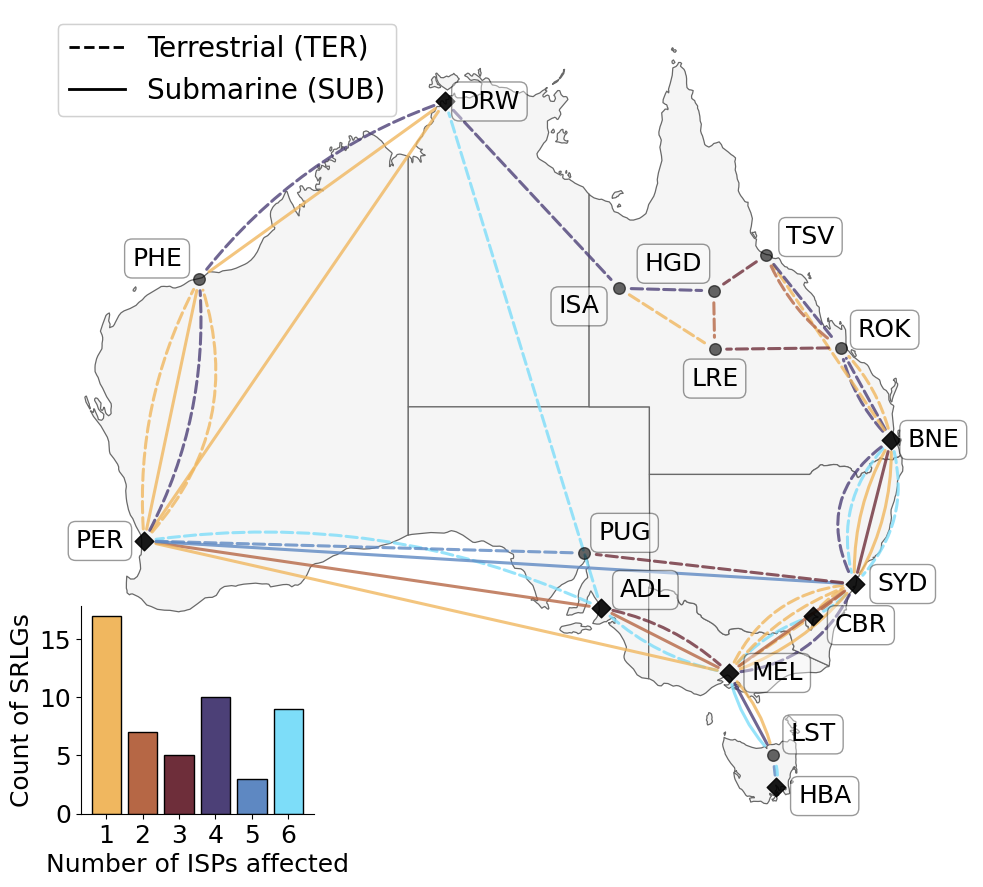

In [27]:
# import packages
import os
import re
import math
import urllib.request
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from collections import defaultdict
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# grab location for AUS state outline
NE_ADMIN1_POLY_ZIP = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces.zip"
NE_ADMIN1_POLY_LOCAL = "ne_50m_admin_1_states_provinces.zip"

POS_ADJUST = {'ADL_1': (2.2,0.8), 'BNE_1': (2.1,0), 'CBR_1': (2.4,-0.4), 'DRW_1': (2.2,0), 'HBA_1': (2.4,-0.4), 'MEL_1': (2.4,0), 'PER_1': (-2.2,0), 'SYD_1': (2.4,0), 'LST_1': (2,0.9), 'PHE_1': (-2.1,0.9), 'TSV_1': (2.2,0.8), 'ROK_1': (2.2,0.8), 'ISA_1': (-2,-0.8), 'HGD_1': (-2,1.2), 'LRE_1': (0,-1.3), 'PUG_1': (2,0.9)}

# custom edge styles for this map
TER_EDGE_STYLES = {'sub': '-', 'road': '--', 'rail': '--', 'rail_road': '--', 'mix': '-.'}
TER_EDGE_LABELS = {'sub': 'Submarine (SUB)', 'road': 'Terrestrial (TER)', 'rail': 'Terrestrial (TER)', 'rail_road': 'Terrestrial (TER)', 'mix': 'Mix'}

# font sizes
plt.rcParams.update({
    "font.size": 18,        # base size
    # "axes.titlesize": 18,
    # "axes.labelsize": 20,
    # "xtick.labelsize": 16,
    # "ytick.labelsize": 16,
    "legend.fontsize": 20,
    "text.usetex": False,
    "font.family": "sans-serif",
    # "font.serif": ["Computer Modern Roman"],
})

# function: load AUS state outline
def load_au_state_polygons():
    if not os.path.exists(NE_ADMIN1_POLY_LOCAL):
        print("Downloading Natural Earth admin-1 state polygons...")
        urllib.request.urlretrieve(NE_ADMIN1_POLY_ZIP, NE_ADMIN1_POLY_LOCAL)

    gdf = gpd.read_file(f"zip://{os.path.abspath(NE_ADMIN1_POLY_LOCAL)}").to_crs("EPSG:4326")

    if "adm0_a3" in gdf.columns:
        gdf = gdf[gdf["adm0_a3"].astype(str).str.upper() == "AUS"]
    elif "admin" in gdf.columns:
        gdf = gdf[gdf["admin"].astype(str).str.lower() == "australia"]
    elif "ADMIN" in gdf.columns:
        gdf = gdf[gdf["ADMIN"].astype(str).str.lower() == "australia"]

    return gdf

# function: get lat and lon values
def safe_pos(G):
    pos = {}
    for n, d in G.nodes(data=True):
        lon, lat = d.get("lon"), d.get("lat")
        try:
            lon, lat = float(lon), float(lat)
        except (TypeError, ValueError):
            continue
        if math.isfinite(lon) and math.isfinite(lat):
            pos[n] = (lon, lat)
    return pos

def site_pair(u, v):
    a, b = u[0], v[0]
    return (a, b) if a <= b else (b, a)

# function: remove edges based on filter
def filter_edges(G):
    out = []
    # go through edges and append
    for u, v, k, d in G.edges(keys=True, data=True):
        if d.get("edge_type") in {"attach", "interconnect"}: # SPECIFY FILTER HERE
            continue
        out.append((u, v, k, d))
    return out

# function: create the srg plot
def plot_srg_aus_deg(G,srg_isp_df):
    # create new df first with the degree column, then dictionary
    srg_degree_df = srg_isp_df.copy()
    srg_degree_df['degree'] = srg_degree_df.sum(axis=1, numeric_only=True)
    srg_deg_dict = dict(zip(srg_degree_df['srg_id'], srg_degree_df['degree']))


    # load au states
    au_states = load_au_state_polygons()

    # get lat/lon values
    pos = safe_pos(G)

    # grab filtered edges
    edges = [(u, v, k, d) for (u, v, k, d) in filter_edges(G) if u in pos and v in pos]

    labels = nx.get_node_attributes(G, 'city')
    abr_labels = {}
    # create abbreviation labels
    for ke in labels.keys():
        ke_abr = ke[:-2]
        abr_labels[ke] = ke_abr

    print(labels)
    print(abr_labels)

    fig, ax = plt.subplots(figsize=(12, 12))

    # basemap
    au_states.plot(ax=ax, color="whitesmoke", edgecolor="dimgray", linewidth=0.9, zorder=0)

    # nodes - IXPs as diamonds, regional as smaller dots
    # first get two lists of the nodes
    node_types = nx.get_node_attributes(G, 'kind')
    ixp_nodes = [key for key, val in node_types.items() if str(val) == 'MPoP']
    regional_nodes = [key for key, val in node_types.items() if str(val) == 'regional']

    # draw nodes for ixps
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        nodelist=ixp_nodes,
        node_size=90,
        node_color="black",
        node_shape="D",
        alpha=0.9
    )

    # draw nodes for regional
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        nodelist=regional_nodes,
        node_size=70,
        node_color="black",
        alpha=0.6
    )

    # city labels offset slightly north for readability
    label_pos = {n: (pos[n][0], pos[n][1] + 0.8) for n in G.nodes}
    # nx.draw_networkx_labels(
    #     G, label_pos, ax=ax,
    #     labels=labels,
    #     font_size=12,
    #     bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.8)
    # )

    seen = defaultdict(int)

    # define colour list
    cmap = plt.get_cmap('managua')
    colours = cmap(np.linspace(0.05, 0.98, 6))
    # colours = plt.cm.Dark2(np.arange(6))
    print(colours)
    
    for u, v, k, d in edges:
        pair = (u, v) if str(u) <= str(v) else (v, u)
        i = seen[pair]
        seen[pair] += 1

        # calculate curvature: 0 for first edge, then alternate sides with increasing radius
        rad = 0.0 if i == 0 else (0.15 * ((i + 1) // 2)) * (1 if i % 2 == 1 else -1)

        # draw edges differently (if sub, rail, road, rail-road)
        # first determine type
        srg_type = d.get("srg_type")
        edge_style = TER_EDGE_STYLES[srg_type]

        # determine edge colour by looking up srg and finding degree
        deg = round(srg_deg_dict[k])

        # then draw the edge
        nx.draw_networkx_edges(
            G, pos, ax=ax,
            edgelist=[(u, v)],
            arrows=True,
            connectionstyle=f"arc3,rad={rad}",
            width=2.2,
            alpha=0.8,
            edge_color=colours[deg-1],
            style=edge_style
        )

    label_pos = {n: (pos[n][0] + POS_ADJUST[n][0], pos[n][1] + POS_ADJUST[n][1]) for n in G.nodes}

    nx.draw_networkx_labels(
        G, label_pos, ax=ax,
        labels=abr_labels,
        font_size=18,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.4)
    )

    # Create legend entries for each edge type
    # legend_lines = [
    #     Line2D([0], [0], lw=2, linestyle=EDGE_STYLES[stype], label=EDGE_LABELS[stype], color = 'black')
    #     for stype in sorted(EDGE_COLOURS.keys()) if stype !='rail' and stype !='mix'
    # ]
    legend_lines = [
        Line2D([0], [0], lw=2, linestyle=TER_EDGE_STYLES[stype], label=TER_EDGE_LABELS[stype], color = 'black')
        for stype in sorted(EDGE_COLOURS.keys()) if stype !='rail' and stype !='mix' and stype !='road'
    ]

    first_legend = ax.legend(handles=legend_lines, loc="upper left")

    # 2. Add the first legend manually as an artist
    ax.add_artist(first_legend)

    # add legend for disconnect type
    # Legend
    colour_dict = {}
    for idx, clr in enumerate(colours):
        colour_dict[idx+1] = clr

    status_order = list(colour_dict.keys())

    handles = [Patch(facecolor=colour_dict[c], edgecolor="none", label=c) for c in status_order]

    # ax.legend(
    #     handles=handles,
    #     title="Number of ISPs",
    #     # bbox_to_anchor=(1.02, 0.5),
    #     loc="upper right",
    #     borderaxespad=0,
    #     ncol=2,
    #     columnspacing=1.2,
    #     handletextpad=0.5,
    #     labelspacing=0.4
    # )

    ## CREATE NEW BAR PLOT AS LEGEND FOR NUMBER OF ISPs
    # create inset axis
    axins = inset_axes(
        ax,
        width="25%",   # width relative to parent
        height="25%",
        bbox_to_anchor=(0.01, 0, 1, 1),
        bbox_transform=ax.transAxes,
        loc="lower left",
        borderpad=1
    )

    # your counts
    unique_vals, counts = np.unique(srg_degree_df['degree'], return_counts=True)
    print(counts)
    print(sum(counts))

    # bar plot inside inset
    axins.bar(unique_vals, counts, color=colours, edgecolor='black', tick_label=list(range(1,len(ISP_LIST)+1)))

    # styling
    # axins.set_title("ISP Count", fontsize=9)
    axins.tick_params(axis='both', labelsize=18)
    # axins.grid(axis='y')
    axins.set_facecolor("none")
    axins.patch.set_alpha(0)
    axins.set_ylabel('Count of SRLGs', fontsize=18)
    axins.set_xlabel('Number of ISPs affected', fontsize=18)

    for tick in axins.yaxis.get_major_ticks():
        tick.label1.set_fontfamily('sans-serif')

    # optional cleanup
    axins.spines['top'].set_visible(False)
    axins.spines['right'].set_visible(False)

    x_min, x_max = ax.get_xlim()
    ax.set_xlim(x_min, x_max + 1.5)
    ax.axis("off")
    plt.savefig(f"images/srg_deg_map.pdf", bbox_inches='tight', transparent=True)
    plt.savefig(f"images/srg_deg_map.svg", bbox_inches='tight', transparent=True)
    plt.show()

# redo the srlg plot, but with degree indicated by colour
plot_srg_aus_deg(G_srg_c,srg_isp_c_df)

In [28]:
srg_degree_df = srg_isp_c_df.copy()
srg_degree_df['degree'] = srg_degree_df.sum(axis=1, numeric_only=True)
srg_deg_dict = dict(zip(srg_degree_df['srg_id'], srg_degree_df['degree']))
print(srg_deg_dict)

{'ADL_DRW_TER_1': 6.0, 'ADL_SMAP_SUB_1': 2.0, 'BNE_ROK_TER_1': 4.0, 'BNE_ROK_TER_2': 1.0, 'BNE_ROK_TER_3': 4.0, 'BNE_TSV_TER_1': 1.0, 'DRW_ISA_TER_1': 4.0, 'DRW_PHE_SUB_1': 1.0, 'DRW_PHE_TER_1': 4.0, 'HBA_LST_TER_1': 5.0, 'HBA_LST_TER_2': 6.0, 'LRE_HGD_TER_1': 2.0, 'LRE_ISA_TER_1': 1.0, 'MEL_ADL_SUB_1': 2.0, 'MEL_ADL_TER_1': 6.0, 'MEL_ADL_TER_2': 3.0, 'MEL_CBR_TER_1': 1.0, 'MEL_CBR_TER_2': 6.0, 'MEL_PER_SUB_1': 1.0, 'MEL_LST_SUB_1': 4.0, 'MEL_LST_SUB_2': 6.0, 'MEL_LST_SUB_3': 1.0, 'ISA_HGD_TER_1': 4.0, 'PER_ADL_SUB_1': 2.0, 'PER_ADL_TER_1': 6.0, 'PER_ADL_TER_2': 5.0, 'PER_DRW_SUB_1': 1.0, 'PER_PHE_SUB_1': 1.0, 'PER_PHE_TER_1': 4.0, 'PER_PHE_TER_2': 1.0, 'PER_PHE_TER_3': 1.0, 'ROK_LRE_TER_1': 3.0, 'SYD_ADL_TER_1': 3.0, 'SYD_BNE_SUB_1': 3.0, 'SYD_BNE_SUB_2': 1.0, 'SYD_BNE_SUB_3': 1.0, 'SYD_BNE_TER_1': 6.0, 'SYD_BNE_TER_2': 6.0, 'SYD_BNE_TER_3': 4.0, 'SYD_CBR_TER_1': 2.0, 'SYD_CBR_TER_2': 6.0, 'SYD_CBR_TER_3': 1.0, 'SYD_MEL_SUB_1': 2.0, 'SYD_MEL_SUB_2': 1.0, 'SYD_MEL_TER_1': 1.0, 'SYD_MEL

[17  7  5 10  3  9]
51


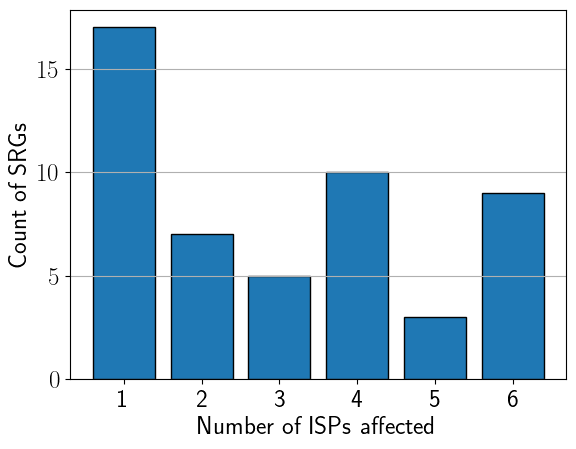

aarnet
abb
optus
superloop
telstra
vocus


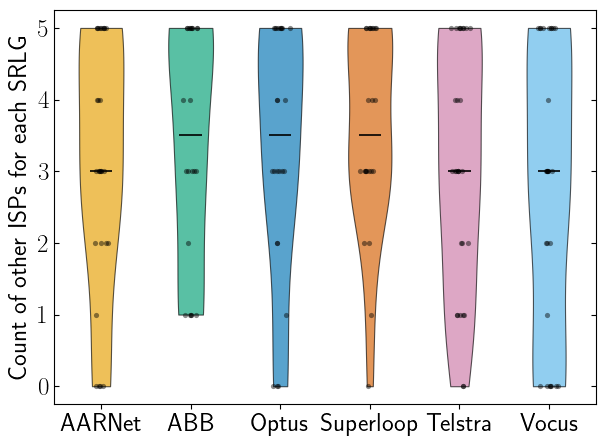

             aarnet       abb     optus  superloop   telstra     vocus
aarnet     0.000000  0.470588  0.313725   0.313725  0.411765  0.313725
abb        0.470588  0.000000  0.352941   0.235294  0.215686  0.549020
optus      0.313725  0.352941  0.000000   0.313725  0.333333  0.470588
superloop  0.313725  0.235294  0.313725   0.000000  0.333333  0.352941
telstra    0.411765  0.215686  0.333333   0.333333  0.000000  0.529412
vocus      0.313725  0.549020  0.470588   0.352941  0.529412  0.000000


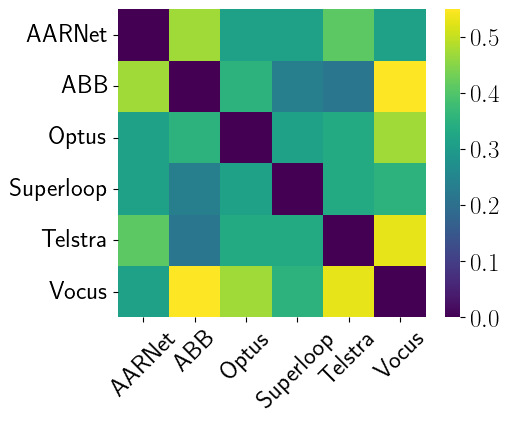

In [29]:
from collections import Counter
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
import pandas as pd
import numpy as np

# font sizes
plt.rcParams.update({
    "font.size": 18,        # base size
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "text.usetex": True,
    "font.family": "sans-serif",
    # "font.serif": ["Computer Modern Roman"],
})

# now compare similarity between isps based on the adjacency matrix
# first srg vs isp
def srg_vs_isp(srg_isp_df):
    df = srg_isp_df.copy()
    # first sum the rows
    df.set_index('srg_id', inplace=True)
    df['total'] = df.sum(axis=1, numeric_only=True)

    # get unique values and their individual counts
    unique_vals, counts = np.unique(df['total'], return_counts=True)
    print(counts)
    print(sum(counts))

    plt.bar(unique_vals, counts, color=SRG_COLOURS['conservative'], edgecolor='black', tick_label=list(range(1,len(ISP_LIST)+1)))
    plt.xlabel('Number of ISPs affected')
    plt.ylabel('Count of SRGs')
    plt.grid(axis='y')
    plt.savefig("images/c_srg_isp_bar.pdf", bbox_inches='tight', transparent=True)
    plt.savefig("images/c_srg_isp_bar.svg", bbox_inches='tight', transparent=True)
    plt.show()

def srg_vs_isp_counts(srg_isp_df):
    df = srg_isp_df.copy()
    # first sum the rows
    df.set_index('srg_id', inplace=True)
    df['total'] = df.sum(axis=1, numeric_only=True)

    # get unique values and their individual counts
    unique_vals, counts = np.unique(df['total'], return_counts=True)
    cumulative_counts = np.flip(np.cumsum(counts))
    return unique_vals.astype(int), cumulative_counts

def srg_vs_isp_dual(srg_df1, srg_df2):
    x1, y1 = srg_vs_isp_counts(srg_df1)
    x2, y2 = srg_vs_isp_counts(srg_df2)

    # Remove 0 category
    x1_mask = x1 > 0
    x2_mask = x2 > 0
    x1, y1 = x1[x1_mask], y1[x1_mask]
    x2, y2 = x2[x2_mask], y2[x2_mask]

    # Use all positive categories that appear
    x = np.array(sorted(set(x1).union(set(x2))))

    y1_full = np.zeros(len(x), dtype=float)
    y2_full = np.zeros(len(x), dtype=float)

    # Map category value -> position in plotting array
    x_to_pos = {val: i for i, val in enumerate(x)}

    for xi, yi in zip(x1, y1):
        y1_full[x_to_pos[xi]] = yi
    for xi, yi in zip(x2, y2):
        y2_full[x_to_pos[xi]] = yi

    print(y1_full)
    print(y2_full)

    width = 0.35
    pos = np.arange(len(x))

    fig, ax = plt.subplots()
    ax.bar(pos - width/2, y1_full, width, label='Conservative',
           color=SRG_COLOURS['conservative'], edgecolor='black')
    ax.bar(pos + width/2, y2_full, width, label='Ideal',
           color=SRG_COLOURS['ideal'], edgecolor='black')

    ax.set_xlabel('Number of ISPs affected')
    ax.set_ylabel('Count of SRLGs')
    # ax.set_title('SRG counts by affected ISP count')
    ax.set_xticks(pos)
    ax.set_xticklabels(x)
    ax.legend()

    plt.tight_layout()
    plt.savefig("images/j_srg_isp_bar.pdf", bbox_inches='tight', transparent=True)
    plt.savefig("images/j_srg_isp_bar.svg", bbox_inches='tight', transparent=True)
    plt.show()

# then ave number isps shared for each of its srgs
def isp_srg_box(srg_isp_df):
    df = srg_isp_df.copy()
    df.set_index('srg_id', inplace=True)
    isp_per_srg = df.sum(axis=1)

    # then get results
    results = []

    for isp in ISP_LIST:
        print(isp)
        # find corresponding srgs
        srg_mask = df[isp] == 1

        # for same srgs, count how many other ISPs also belong to it
        other_srg_counts = isp_per_srg[srg_mask] - 1
        
        results.append(other_srg_counts)

    # print summary of results
    summary = pd.DataFrame(results, columns = list(ISP_LABELS.values()))

    # Plot
    fig, ax = plt.subplots()

    bplot = ax.boxplot(results, patch_artist=True, tick_labels=list(ISP_LABELS.values()),medianprops={'color': 'black'})

    # fill with colors
    for patch, isp in zip(bplot['boxes'], ISP_LIST):
        patch.set_facecolor(ISP_COLOURS[isp])


    # plt.xticks(x, summary["isp"], rotation=45)
    plt.ylabel("Count of other ISPs for each SRLG")
    # plt.xlabel("ISP")
    # plt.title("Shared SRGs per ISP")
    # plt.legend()
    plt.tick_params(axis='y', which='both', right=True, labelright=False, direction='in')
    plt.tight_layout()
    plt.savefig("images/c_isp_shared_box.pdf", bbox_inches='tight',transparent=True)
    plt.savefig("images/c_isp_shared_box.svg", bbox_inches='tight',transparent=True)
    plt.show()

# then ave number isps shared for each of its srgs
def isp_srg_violin(srg_isp_df):
    df = srg_isp_df.copy()
    df.set_index('srg_id', inplace=True)
    isp_per_srg = df.sum(axis=1)

    results = []

    for isp in ISP_LIST:
        print(isp)

        srg_mask = df[isp] == 1
        other_srg_counts = isp_per_srg[srg_mask] - 1
        results.append(other_srg_counts.dropna().values)

    # optional summary
    summary = pd.DataFrame({
        isp_label: pd.Series(vals)
        for isp_label, vals in zip(ISP_LABELS.values(), results)
    })

    
    # Plot
    fig, ax = plt.subplots()

    # positions = np.arange(1, len(ISP_LIST) * 1.4, 1.4)
    positions = np.arange(1, len(ISP_LIST) + 1)

    vplot = ax.violinplot(
        results,
        positions=positions,
        showmeans=False,
        showmedians=True,
        showextrema=False
    )

    # violin shading by ISP colour
    for body, isp in zip(vplot['bodies'], ISP_LIST):
        body.set_facecolor(ISP_COLOURS[isp])
        body.set_edgecolor('black')
        body.set_alpha(0.65)
        body.set_linewidth(0.8)

    # median line
    vplot['cmedians'].set_color('black')
    vplot['cmedians'].set_linewidth(1.2)

    # overlay monochrome scatter points
    for i, vals in enumerate(results, start=1):
        jitter = np.random.normal(0, 0.045, size=len(vals))
        ax.scatter(
            np.full(len(vals), i) + jitter,
            vals,
            s=14,
            color='black',
            alpha=0.45,
            linewidths=0,
            zorder=3
        )

    ax.set_xticks(positions)
    ax.set_xticklabels(list(ISP_LABELS.values()))

    ax.set_ylabel("Count of other ISPs for each SRLG")

    ax.tick_params(axis='y', which='both', right=True, labelright=False, direction='in')

    plt.tight_layout()
    plt.savefig("images/c_isp_shared_violin.pdf", bbox_inches='tight', transparent=True)
    plt.savefig("images/c_isp_shared_violin.svg", bbox_inches='tight', transparent=True)
    plt.show()


# then risk comparison
# Compute pairwise proportion of differences
# Transpose df because pdist calculates distance between rows
def risk_heatmap(srg_isp_df):
    df = srg_isp_df.copy()
    df.set_index('srg_id', inplace=True)
    dist_array = pdist(df.T, metric='hamming')

    # Convert to a readable square matrix (DataFrame)
    dist_matrix = squareform(dist_array)
    hamming_df = pd.DataFrame(dist_matrix, index=df.columns, columns=df.columns)

    print(hamming_df)
    # Convert proportions to absolute bit counts
    absolute_hamming_df = (hamming_df*len(df)).astype(int)

    # make heatmap
    plt.figure(figsize=(5, 4)) 
    sns.heatmap(hamming_df, square=True, cmap='viridis', xticklabels=list(ISP_LABELS.values()), yticklabels=list(ISP_LABELS.values()))
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)

    plt.savefig("images/c_isp_heatmap.pdf", bbox_inches='tight',transparent=True)
    plt.savefig("images/c_isp_heatmap.svg", bbox_inches='tight',transparent=True)
    plt.show()

srg_vs_isp(srg_isp_c_df)
# srg_vs_isp_dual(srg_isp_c_df, srg_isp_i_df)
# isp_srg_box(srg_isp_c_df)
isp_srg_violin(srg_isp_c_df)
risk_heatmap(srg_isp_c_df)

## Can also get ISP stats (but we won't)

In [30]:
city_outages_c_df.describe()
scatter_df = pd.DataFrame(columns=['isp','isp_fails','global_fails','mean_k','mean_neighbour_k'])

# overall first
fail_counts = {}
overlap_counts = {}

global_condition = outages_c_df['n_components'] > 1
global_fail_count = global_condition.sum()

for isp in ISP_LIST:
    isp_condition = outages_c_df[f'{isp}_n_components'] > 1
    
    fail_counts[isp] = isp_condition.sum()
    
    # overlap = both ISP fail AND global fail
    overlap_counts[isp] = (isp_condition & global_condition).sum()

labels = [isp.upper() for isp in ISP_LIST]

for isp in ISP_LIST:
    row = {}
    row['isp'] = isp
    row['mean_k'] = city_outages_c_df[f'{isp}_degree_internal']
    row['mean_neighbour_k'] = city_outages_c_df[f'{isp}_avg_neighbor_degree_internal'].mean()
    row['isp_fails'] = fail_counts[isp] 
    row['global_fails'] = overlap_counts[isp]
    scatter_df.loc[len(scatter_df)] = row

print(scatter_df)

         isp  isp_fails  global_fails  \
0     aarnet          7             3   
1        abb          7             7   
2      optus          5             5   
3  superloop          7             7   
4    telstra          6             6   
5      vocus        105            11   

                                              mean_k  mean_neighbour_k  
0  0     5
1     6
2     3
3     2
4     2
5     ...          4.121795  
1  0      6
1      3
2      3
3      2
4      2
5...          4.261538  
2  0     5
1     6
2     2
3     2
4     2
5     ...          3.974359  
3  0      5
1      5
2      2
3      3
4      2
5...          3.984615  
4  0     5
1     5
2     4
3     3
4     2
5     ...          3.608974  
5  0     5
1     6
2     4
3     4
4     1
5     ...          4.606410  


### Plot failures per ISP (but we won't)

In [31]:
# import matplotlib.pyplot as plt
# import numpy as np
# from matplotlib.patches import Patch
# from matplotlib.lines import Line2D
# from matplotlib.cm import ScalarMappable
# from matplotlib.colors import Normalize

# plt.rcParams.update({
#     'font.size': 14,
#     'axes.labelsize': 14,
# })

# # ISP to marker mapping
# # isp_markers = {'aarnet': 'o', 'abb': 's', 'optus': '^', 'telstra': 'D'}

# fig, ax = plt.subplots(figsize=(11, 6))

# # Prepare boolean flag: does this ISP row correspond to any global failure?
# scatter_df['global_flag'] = scatter_df['global_fails'] > 0

# # Colour mapping for global / not-global
# colour_map = {True: 'tab:red', False: 'tab:gray'}

# # Plot: x = mean_k, y = number of ISP failures; colour = global_flag; marker = ISP
# for isp in scatter_df['isp'].unique():
#     for global_flag in [False, True]:
#         mask = (scatter_df['isp'] == isp) & (scatter_df['global_flag'] == global_flag)
#         data = scatter_df.loc[mask]
#         if data.empty:
#             continue
#         ax.scatter(
#             data['mean_k'],
#             data['isp_fails'],                 # y-axis = number of failures
#             c=[colour_map[global_flag]],
#             # marker=isp_markers.get(isp, 'o'),
#             s=150,
#             alpha=0.8,
#             edgecolors='black',
#             linewidth=1,
#             label=f"{isp.upper()} {'(global)' if global_flag else '(local)'}"
#         )

# ax.set_xlabel('Mean Node Degree')
# ax.set_ylabel('Number of ISP Failures')
# ax.grid(True)
# # Build concise legend (unique labels only)
# handles, labels = ax.get_legend_handles_labels()
# by_label = dict(zip(labels, handles))
# ax.legend(by_label.values(), by_label.keys(), loc='upper left', fontsize=10)

# plt.tight_layout()
# plt.show()
# # ...existing code...

# Final Plots
## City Scatter Plots

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


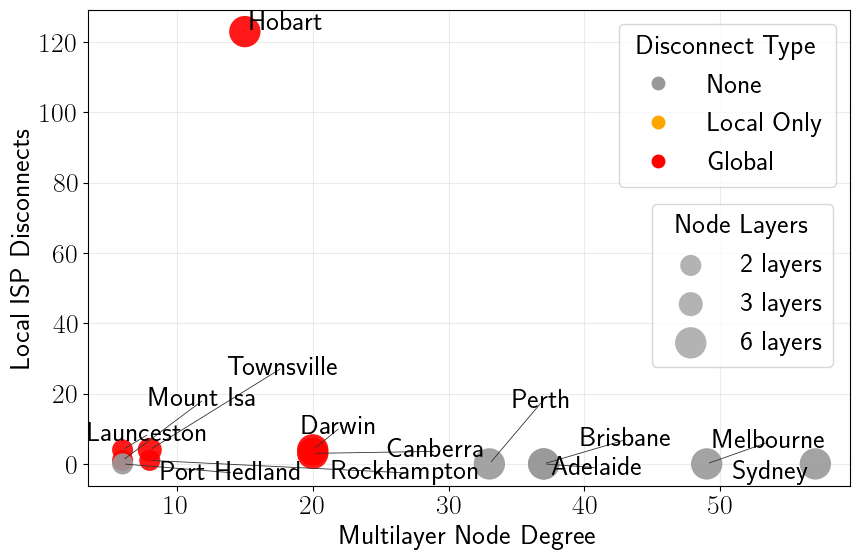

In [32]:
# if not installed yet
# pip install adjustText

import matplotlib.pyplot as plt
from adjustText import adjust_text
import numpy as np
import matplotlib.lines as mlines

# -----------------------------
# City code -> full name
# -----------------------------

CITY_MAP = {
    "SYD_1": "Sydney",
    "MEL_1": "Melbourne",
    "ADL_1": "Adelaide",
    "BNE_1": "Brisbane",
    "PER_1": "Perth",
    "CBR_1": "Canberra",
    "DRW_1": "Darwin",
    "HBA_1": "Hobart",
    "ROK_1": "Rockhampton",
    "LST_1": "Launceston",
    "TSV_1": "Townsville",
    "ISA_1": "Mount Isa",
    "PHE_1": "Port Hedland",
}

# -----------------------------
# Columns
# -----------------------------
CITY_COL   = "site"
X_COL      = "supra_degree_sum"        # x-axis
Y_COL      = "isp_fails"               # y-axis
GLOBAL_COL = "global_fails"            # 0/1 or count
SIZE_COL   = "supra_nodes_present"     # marker size

plt.rcParams.update({
    "font.size": 20,        # base size
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
    "text.usetex": True,
    "font.family": "sans-serif",
    # "font.serif": ["Computer Modern Roman"],
})

dfp = city_outages_c_df.copy()
dfp["city_name"] = dfp[CITY_COL].map(CITY_MAP).fillna(dfp[CITY_COL])

# numeric safety
dfp[X_COL] = dfp[X_COL].astype(float)
dfp[Y_COL] = dfp[Y_COL].astype(float)
dfp[GLOBAL_COL] = dfp[GLOBAL_COL].astype(int)
dfp[SIZE_COL] = dfp[SIZE_COL].astype(int)

# -----------------------------
# 3-class colour status
# -----------------------------
def classify(row):
    if row[GLOBAL_COL] > 0:
        return "Global fail"
    elif row[Y_COL] > 0:
        return "Local-only fails"
    else:
        return "No fails"

dfp["status"] = dfp.apply(classify, axis=1)

status_colors = {
    "Global fail": "red",
    "Local-only fails": "orange",
    "No fails": "0.6",
}

# -----------------------------
# Marker size from supra_nodes_present
# (1–4 layers → visually distinct but not huge)
# -----------------------------
sizes = 90 + 70 * dfp[SIZE_COL].to_numpy()

# -----------------------------
# Keep points EXACTLY aligned to axes
# (no jitter; only labels move)
# -----------------------------
x = dfp[X_COL].to_numpy()
y = dfp[Y_COL].to_numpy()
colors = dfp["status"].map(status_colors)

plt.figure(figsize=(9, 6))

plt.scatter(
    x, y,
    s=sizes,
    c=colors,
    marker="o",
    alpha=0.9,
    edgecolor="none",
    zorder=3
)

# -----------------------------
# Labels
# -----------------------------
texts = []
for _, r in dfp.iterrows():
    texts.append(
        plt.text(r[X_COL], r[Y_COL], str(r["city_name"]), fontsize=20, zorder=4)
    )

adjust_text(
    texts,
    x=x, y=y,
    expand_points=(1.4, 1.4),
    expand_text=(1.6, 1.6),
    force_text=(0.7, 0.7),
    force_points=(0.3, 0.3),
    only_move={"points": "none", "text": "xy"},
    arrowprops=dict(arrowstyle="-", lw=0.6, color="0.2"),
)

# -----------------------------
# Legends
# -----------------------------
# Colour legend
color_handles = [
    mlines.Line2D([], [], color=status_colors["No fails"], marker="o", linestyle="None",
                  markersize=9, label="None"),
    mlines.Line2D([], [], color=status_colors["Local-only fails"], marker="o", linestyle="None",
                  markersize=9, label="Local Only"),
    mlines.Line2D([], [], color=status_colors["Global fail"], marker="o", linestyle="None",
                  markersize=9, label="Global"),
]
leg1 = plt.legend(handles=color_handles, title="Disconnect Type", loc="upper right", frameon=True)
plt.gca().add_artist(leg1)

# Size legend for supra_nodes_present
layer_levels = sorted(dfp[SIZE_COL].unique())
size_handles = [
    plt.scatter([], [], s=(90 + 70 * L), color="0.7", edgecolor="none",
                label=f"{L} layer{'s' if L != 1 else ''}")
    for L in layer_levels
]

plt.legend(handles=size_handles, title="Node Layers", loc=(0.74, 0.25), frameon=True)

# -----------------------------
# Axes + Title
# -----------------------------
plt.xlabel("Multilayer Node Degree")
plt.ylabel("Local ISP Disconnects")
# plt.title("City reliability: degree vs local fails")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('images/c_node_deg_city.pdf', transparent=True)
plt.savefig('images/c_node_deg_city.svg', transparent=True)
plt.show()


In [33]:
dfp

,site,supra_nodes_present,supra_degree_sum,supra_avg_neighbor_degree_mean,aarnet_degree_internal,aarnet_avg_neighbor_degree_internal,abb_degree_internal,abb_avg_neighbor_degree_internal,optus_degree_internal,optus_avg_neighbor_degree_internal,...,superloop_avg_neighbor_degree_internal,telstra_degree_internal,telstra_avg_neighbor_degree_internal,vocus_degree_internal,vocus_avg_neighbor_degree_internal,ixp_count,isp_fails,global_fails,city_name,status
0,ADL_1,6,37.0,6.133333,5,3.666667,6,6.0,5,4.333333,...,6.500000,5,5.000000,5,6.000000,6,0.0,0,Adelaide,No fails
1,BNE_1,6,37.0,6.444444,6,6.500000,3,10.0,6,3.666667,...,7.000000,5,6.000000,6,4.333333,6,0.0,0,Brisbane,No fails
2,CBR_1,6,20.0,8.138889,3,6.500000,3,9.0,2,6.000000,...,9.500000,4,8.000000,4,8.000000,2,3.0,1,Canberra,Global fail
3,DRW_1,6,20.0,5.030556,2,4.000000,2,5.0,2,4.000000,...,4.666667,3,5.000000,4,4.250000,4,4.0,2,Darwin,Global fail
4,HBA_1,6,15.0,5.666667,2,6.000000,2,5.0,2,4.000000,...,8.000000,2,7.000000,1,8.000000,4,123.0,6,Hobart,Global fail
5,MEL_1,6,49.0,5.505556,6,4.250000,8,4.6,6,4.250000,...,5.000000,7,5.000000,8,4.800000,6,0.0,0,Melbourne,No fails
6,PER_1,6,33.0,6.327778,3,6.000000,4,6.0,5,4.666667,...,6.333333,5,5.666667,6,5.000000,6,0.0,0,Perth,No fails
7,SYD_1,6,57.0,5.872222,7,4.500000,10,4.8,6,4.750000,...,4.800000,9,5.250000,8,6.000000,6,0.0,0,Sydney,No fails
8,TSV_1,3,8.0,4.666667,3,4.500000,0,0.0,3,4.000000,...,0.000000,0,0.000000,2,4.500000,0,4.0,4,Townsville,Global fail
9,ROK_1,2,8.0,4.666667,6,4.000000,0,0.0,2,4.500000,...,0.000000,0,0.000000,0,0.000000,0,1.0,1,Rockhampton,Global fail


## Disconnect count stats 

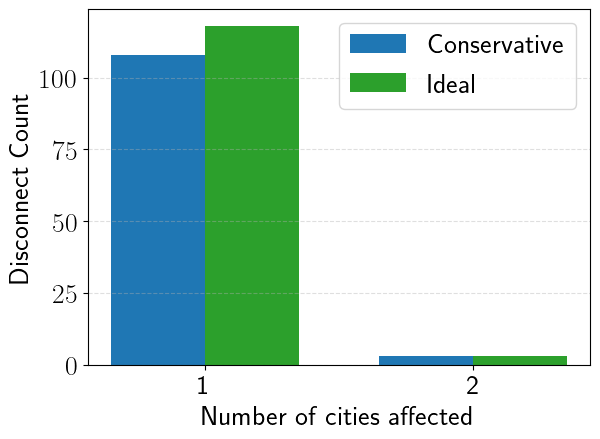

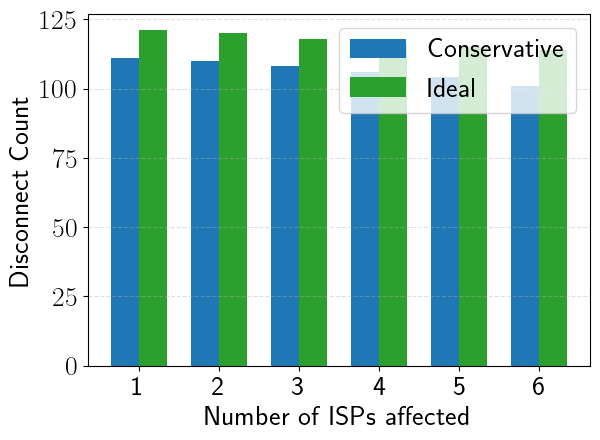

In [34]:
import matplotlib.pyplot as plt
import numpy as np

def city_failures(fail_c_df, fail_i_df):
    failc = fail_c_df.copy()
    faili = fail_i_df.copy()

    unique_vals_c, counts_c = np.unique(failc['n_cities'], return_counts=True)
    unique_vals_i, counts_i = np.unique(faili['n_cities'], return_counts=True)

    # calculate cumulative counts (count if <= integer value)
    cumulative_counts_c = np.flip(np.cumsum(counts_c))
    cumulative_counts_i = np.flip(np.cumsum(counts_i))

    # use the union of categories so bars align
    x = np.arange(1, max(unique_vals_c.max(), unique_vals_i.max()) + 1)
    y1_full = np.zeros_like(x, dtype=float)
    y2_full = np.zeros_like(x, dtype=float)

    for xi, yi in zip(unique_vals_c, counts_c):
        y1_full[xi - 1] = yi
    for xi, yi in zip(unique_vals_i, counts_i):
        y2_full[xi - 1] = yi

    width = 0.35
    fig, ax = plt.subplots()
    ax.bar(x - width/2, y1_full, width, label='Conservative', color='tab:blue')
    ax.bar(x + width/2, y2_full, width, label='Ideal', color='tab:green')

    ax.set_xlabel('Number of cities affected')
    ax.set_ylabel('Disconnect Count')
    ax.set_xticks(x)
    ax.set_xticklabels(x)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.savefig('images/city_fail_bar.pdf', transparent=True)
    plt.show()

def isp_failures(fail_c_df, fail_i_df):
    failc = fail_c_df.copy()
    faili = fail_i_df.copy()

    unique_vals_c, counts_c = np.unique(failc['n_isps'], return_counts=True)
    unique_vals_i, counts_i = np.unique(faili['n_isps'], return_counts=True)

    # calculate cumulative counts (count if <= integer value)
    cumulative_counts_c = np.flip(np.cumsum(counts_c))
    cumulative_counts_i = np.flip(np.cumsum(counts_i))

    # use the union of categories so bars align
    x = np.arange(1, max(unique_vals_c.max(), unique_vals_i.max()) + 1)
    y1_full = np.zeros_like(x, dtype=float)
    y2_full = np.zeros_like(x, dtype=float)

    for xi, yi in zip(unique_vals_c, cumulative_counts_c):
        y1_full[xi - 1] = yi
    for xi, yi in zip(unique_vals_i, cumulative_counts_i):
        y2_full[xi - 1] = yi

    width = 0.35
    fig, ax = plt.subplots()
    ax.bar(x - width/2, y1_full, width, label='Conservative', color='tab:blue')
    ax.bar(x + width/2, y2_full, width, label='Ideal', color='tab:green')

    ax.set_xlabel('Number of ISPs affected')
    ax.set_ylabel('Disconnect Count')
    ax.set_xticks(x)
    ax.set_xticklabels(x)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    plt.savefig('images/isp_fail_bar.pdf', transparent=True)
    plt.show()


def edge_failures(fail_c_df, fail_i_df, srg_c, srg_i):
    failc = fail_c_df.copy()
    faili = fail_i_df.copy()

    # first create a new column corresponding to the number of edges for that srg

    unique_vals_c, counts_c = np.unique(failc['n_isps'], return_counts=True)
    unique_vals_i, counts_i = np.unique(faili['n_isps'], return_counts=True)

    # calculate cumulative counts (count if <= integer value)
    cumulative_counts_c = np.flip(np.cumsum(counts_c))
    cumulative_counts_i = np.flip(np.cumsum(counts_i))

    # use the union of categories so bars align
    x = np.arange(1, max(unique_vals_c.max(), unique_vals_i.max()) + 1)
    y1_full = np.zeros_like(x, dtype=float)
    y2_full = np.zeros_like(x, dtype=float)

    for xi, yi in zip(unique_vals_c, cumulative_counts_c):
        y1_full[xi - 1] = yi
    for xi, yi in zip(unique_vals_i, cumulative_counts_i):
        y2_full[xi - 1] = yi

    width = 0.35
    fig, ax = plt.subplots()
    ax.bar(x - width/2, y1_full, width, label='Conservative', color='tab:blue')
    ax.bar(x + width/2, y2_full, width, label='Ideal', color='tab:green')

    ax.set_xlabel('Number of ISPs affected')
    ax.set_ylabel('Disconnect Count')
    ax.set_xticks(x)
    ax.set_xticklabels(x)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.legend()
    plt.tight_layout()
    
    plt.show()
    dfc['edge_count'] = dfc['edges'].apply(len)
    dfi['edge_count'] = dfi['edges'].apply(len)

city_failures(fail_sum_c_df, fail_sum_i_df)
isp_failures(fail_sum_c_df, fail_sum_i_df)
# edge_failures(fail_sum_c_df, fail_sum_i_df, srg_c_df, srg_i_df)

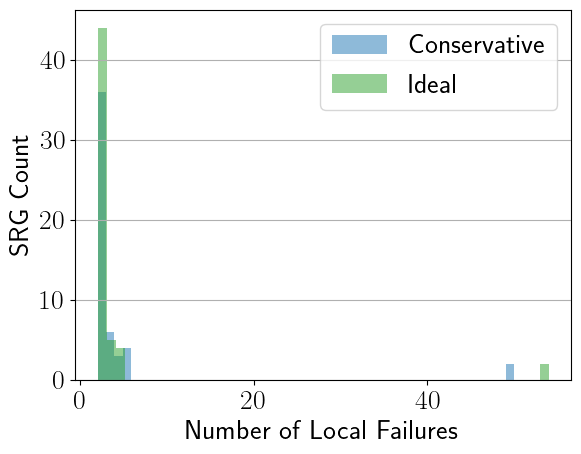

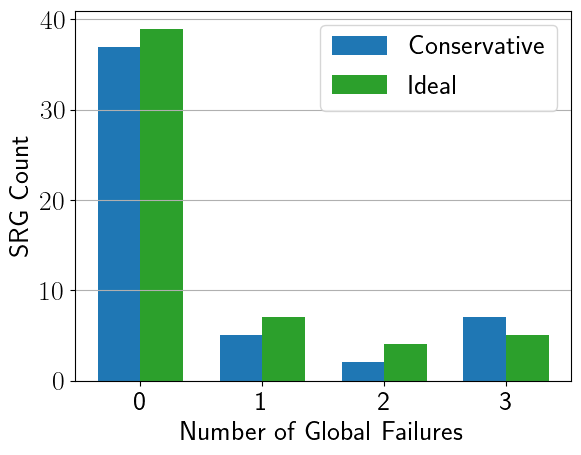

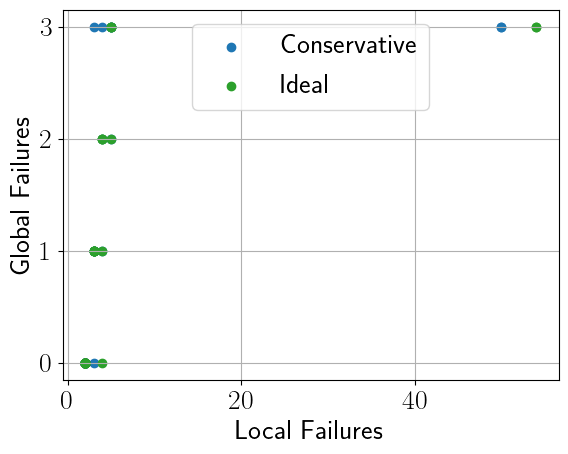

In [35]:
# Rail vs Road


# GLOBAL VS LOCAL per SRG
# srg_sum_i_df

# Plot both histograms
plt.hist(srg_sum_c_df['local_outages'], bins=50, alpha=0.5, label='Conservative', color='tab:blue')
plt.hist(srg_sum_i_df['local_outages'], bins=50, alpha=0.5, label='Ideal', color='tab:green')

# Add legend and labels
plt.legend(loc='upper right')
plt.xlabel('Number of Local Failures')
plt.ylabel('SRG Count')
plt.grid(axis='y')
plt.savefig('images/local_srg.pdf', transparent=True)
plt.show()

counts_c = srg_sum_c_df['global_outages'].value_counts().sort_index()
counts_i = srg_sum_i_df['global_outages'].value_counts().sort_index()

# Align the data
all_vals = sorted(set(counts_c.index) | set(counts_i.index))
counts_c = counts_c.reindex(all_vals, fill_value=0)
counts_i = counts_i.reindex(all_vals, fill_value=0)

x = np.arange(len(all_vals))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x - width/2, counts_c, width, label='Conservative', color='tab:blue')
ax.bar(x + width/2, counts_i, width, label='Ideal', color='tab:green')

ax.set_xlabel('Number of Global Failures')
ax.set_ylabel('SRG Count')
ax.set_xticks(x)
ax.set_xticklabels(all_vals)
ax.legend(loc='upper right')
ax.grid(axis='y')
plt.savefig('images/global_srg.pdf', transparent=True)
plt.show()

# scatter plot comparing
plt.scatter(srg_sum_c_df['local_outages'], srg_sum_c_df['global_outages'], label='Conservative', color='tab:blue')
plt.scatter(srg_sum_i_df['local_outages'], srg_sum_i_df['global_outages'], label='Ideal', color='tab:green')
plt.legend(loc='upper center')
plt.xlabel('Local Failures')
plt.ylabel('Global Failures')
plt.yticks([0,1,2,3])
plt.grid()
plt.savefig('images/local_global.pdf', transparent=True)
plt.show()

In [36]:
srg_sum_c_df

,srg_id,local_outages,global_outages,local_only_outages
0,HBA_LST_TER_1,4,3,1
1,HBA_LST_TER_2,50,3,47
2,MEL_LST_SUB_1,3,3,0
3,MEL_CBR_TER_2,3,1,2
4,ADL_DRW_TER_1,5,2,3
5,ISA_HGD_TER_1,5,3,2
6,TSV_HGD_TER_1,4,2,2
7,DRW_ISA_TER_1,4,1,3
8,BNE_ROK_TER_1,5,3,2
9,ADL_SMAP_SUB_1,2,0,2


## ISP stacked bar chart

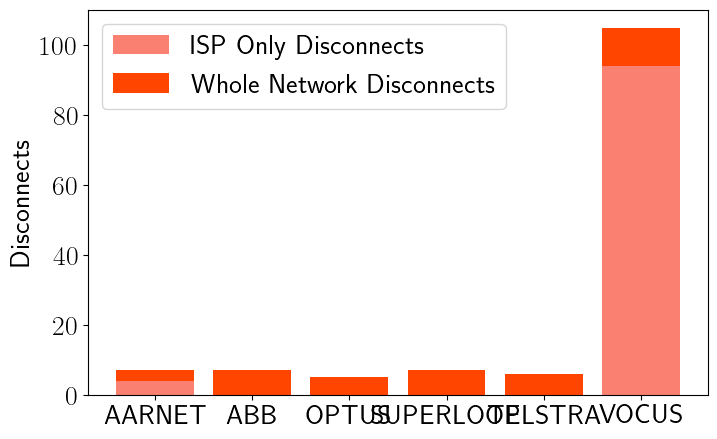

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# bar plot of number of failures by isp and overall
# overall first
fail_counts = {}
overlap_counts = {}

global_condition = outages_c_df['n_components'] > 1
global_fail_count = global_condition.sum()

for isp in ISP_LIST:
    isp_condition = outages_c_df[f'{isp}_n_components'] > 1
    
    fail_counts[isp] = isp_condition.sum()
    
    # overlap = both ISP fail AND global fail
    overlap_counts[isp] = (isp_condition & global_condition).sum()

labels = [isp.upper() for isp in ISP_LIST]

total_vals = [fail_counts[isp] for isp in ISP_LIST]
overlap_vals = [overlap_counts[isp] for isp in ISP_LIST]

non_overlap_vals = [
    total_vals[i] - overlap_vals[i] 
    for i in range(len(total_vals))
]


x = np.arange(len(labels))

plt.figure(figsize=(8, 5))
plt.rcParams.update({'font.size': 16})

plt.bar(x, non_overlap_vals, label='ISP Only Disconnects', color='salmon')
plt.bar(x, overlap_vals, bottom=non_overlap_vals, color='orangered',
        label='Whole Network Disconnects')

plt.xticks(x, labels)
plt.ylabel('Disconnects')
plt.legend(loc='upper left')
# plt.title('Failures by ISP with Global Overlap Highlighted')
plt.savefig("failure_counts.svg", bbox_inches='tight',transparent=True)
plt.show()

## Heatmaps of SRG pairs

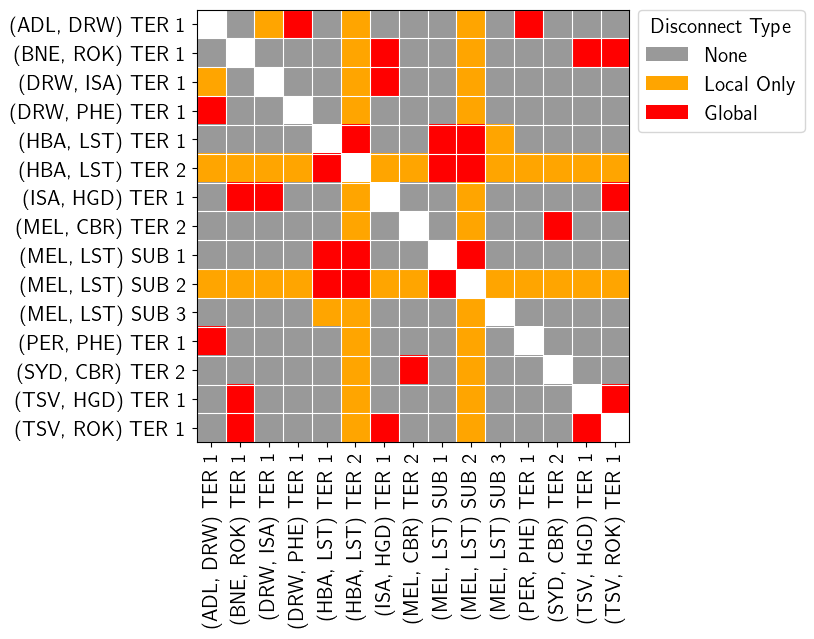

In [38]:
# heat map
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

fontsize = 15
plt.rcParams.update({
    "font.size": fontsize,        # base size
    "axes.titlesize": fontsize,
    "axes.labelsize": fontsize,
    "xtick.labelsize": fontsize,
    "ytick.labelsize": fontsize,
    "legend.fontsize": fontsize,
    "text.usetex": True,
    "font.family": "sans-serif",
    # "font.serif": ["Computer Modern Roman"],
})

status_colours = {
    "None": "0.6",
    "Local Only": "orange",
    "Global": "red",
}

def plot_srg_pair_heatmap(
    df_pairs,
    srg_sum_df,
    # metric_col="largest_cc_frac",     # <-- change to your chosen metric
    srg1_col="srg_id_1",
    srg2_col="srg_id_2",
    figsize_scale=0.5,
    # agg="min",                       # if duplicate pairs exist
    diagonal_value=np.nan,
    diagonal_colour="white",
):
    """
    Upper-triangle heatmap where entry (i,j) is the impact metric for pair (SRGi, SRGj).

    metric_col suggestions:
      - "largest_cc_frac"
      - "capitals_in_largest_cc_frac"
      - "supra_cap_pair_frac"
    """

    # copy the df
    df = df_pairs[["srg_id_1", "srg_id_2"]].copy()
    
    # first remove the baseline row
    df = df.dropna(subset=['srg_id_1', 'srg_id_2'])
    
    # make sure columns are strings
    df[srg1_col] = df[srg1_col].astype(str)
    df[srg2_col] = df[srg2_col].astype(str)

    # add columns for whether a local or global disconnect occurred
    df['local_fail'] = (double_srg_c_df[['aarnet_n_components', 'abb_n_components', 'optus_n_components', 'telstra_n_components', 'vocus_n_components','superloop_n_components']] > 1).any(axis=1)
    df['global_fail'] = (double_srg_c_df[['n_components']] > 1).any(axis=1)
    
    # create class column (0 = no outage, 1 = local outage only, 2 = global outage)
    df['class'] = 0

    for idx, row in df.iterrows():
        # first check both srg_1 and srg_2 column. If know that they do not have more than 2 local disconnects, filter out
        srg1 = row[srg1_col]
        srg2 = row[srg2_col]
        local_count_1 = srg_sum_df.loc[srg_sum_df['srg_id'] == srg1, 'local_outages'].iloc[0]
        local_count_2 = srg_sum_df.loc[srg_sum_df['srg_id'] == srg2, 'local_outages'].iloc[0]
        global_count_1 = srg_sum_df.loc[srg_sum_df['srg_id'] == srg1, 'global_outages'].iloc[0]
        global_count_2 = srg_sum_df.loc[srg_sum_df['srg_id'] == srg2, 'global_outages'].iloc[0]
        if (local_count_1 <= 2 and global_count_1 == 0) or (local_count_2 <= 2 and global_count_2 == 0): 
            df.at[idx, 'class'] = np.nan
            continue
        elif row['global_fail']:
            df.at[idx, 'class'] = 2
        elif row['local_fail']:
            df.at[idx, 'class'] = 1

    df = df.dropna(subset=['class'])

    # canonicalise pair ordering so (A,B) and (B,A) match
    a = np.minimum(df[srg1_col].values, df[srg2_col].values)
    b = np.maximum(df[srg1_col].values, df[srg2_col].values)
    df["srgA"] = a
    df["srgB"] = b


    # list of SRGs involved in any pair
    srgs = sorted(set(df["srgA"]).union(set(df["srgB"])))

    # create more readable labels for the SRGs
    srg_labels = [f'({srg[0:3]}, {srg[4:7]}) {srg[-5:-2]} {srg[-1:]}' for srg in srgs]

    # use the order from the colour mapping as well
    status_order = list(status_colours.keys())

    # map to the integers
    class_to_int = {cls: i for i, cls in enumerate(status_order)}
    int_to_class = {i: cls for cls, i in class_to_int.items()}

    d_rev = df.rename(columns={"srg_id_1": "srg_id_2", "srg_id_2": "srg_id_1"})
    d_sym = pd.concat([df, d_rev], ignore_index=True)


    # Pivot into matrix
    mat = d_sym.pivot(index="srg_id_1", columns="srg_id_2", values="class")

    # Reindex so rows/cols match and all SRGs appear
    mat = mat.reindex(index=srgs, columns=srgs)
    
    # Set diagonal
    if pd.isna(diagonal_value):
        np.fill_diagonal(mat.values, np.nan)
    else:
        if diagonal_value not in class_to_int:
            raise ValueError(
                f"diagonal_value='{diagonal_value}' is not one of {list(class_to_int.keys())}"
            )
        np.fill_diagonal(mat.values, class_to_int[diagonal_value])

    # Colormap and norm for categorical values
    cmap = ListedColormap([status_colours[c] for c in status_order])
    cmap.set_bad(diagonal_colour)   # also used for any missing combinations

    bounds = np.arange(len(status_order) + 1) - 0.5
    norm = BoundaryNorm(bounds, cmap.N)

    # Figure size
    n = len(srgs)
    fig_w = max(8, n * figsize_scale)
    fig_h = max(6, n * figsize_scale)

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(mat.values, cmap=cmap, norm=norm, aspect="equal", interpolation="none")

    # Ticks and labels
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(srg_labels, rotation=90)
    ax.set_yticklabels(srg_labels)

    # Gridlines between cells
    ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=0.8)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Legend
    handles = [Patch(facecolor=status_colours[c], edgecolor="none", label=c) for c in status_order]
    if pd.isna(diagonal_value):
        handles.append(Patch(facecolor=diagonal_colour, edgecolor="none"))

    ax.legend(
        handles=handles[:3],
        title="Disconnect Type",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0
    )

    plt.tight_layout()
    plt.savefig('images/fail_heatmap.pdf', transparent=True)
    plt.savefig('images/fail_heatmap.svg', transparent=True)
    plt.show()


# Example usage:
# plot_srg_pair_heatmap(df_pairs, metric_col="capitals_in_largest_cc_frac")
plot_srg_pair_heatmap(double_srg_c_df, srg_sum_c_df)

    

## SRG Failure Map

{'ADL_1': 'Adelaide', 'BNE_1': 'Brisbane', 'CBR_1': 'Canberra', 'DRW_1': 'Darwin', 'HBA_1': 'Hobart', 'MEL_1': 'Melbourne', 'PER_1': 'Perth', 'SYD_1': 'Sydney', 'LST_1': 'Launceston', 'PHE_1': 'Port Hedland', 'TSV_1': 'Townsville', 'ROK_1': 'Rockhampton', 'ISA_1': 'Mount Isa', 'HGD_1': 'Hughenden', 'LRE_1': 'Longreach', 'PUG_1': 'Port Augusta'}
{'ADL_1': 'ADL', 'BNE_1': 'BNE', 'CBR_1': 'CBR', 'DRW_1': 'DRW', 'HBA_1': 'HBA', 'MEL_1': 'MEL', 'PER_1': 'PER', 'SYD_1': 'SYD', 'LST_1': 'LST', 'PHE_1': 'PHE', 'TSV_1': 'TSV', 'ROK_1': 'ROK', 'ISA_1': 'ISA', 'HGD_1': 'HGD', 'LRE_1': 'LRE', 'PUG_1': 'PUG'}


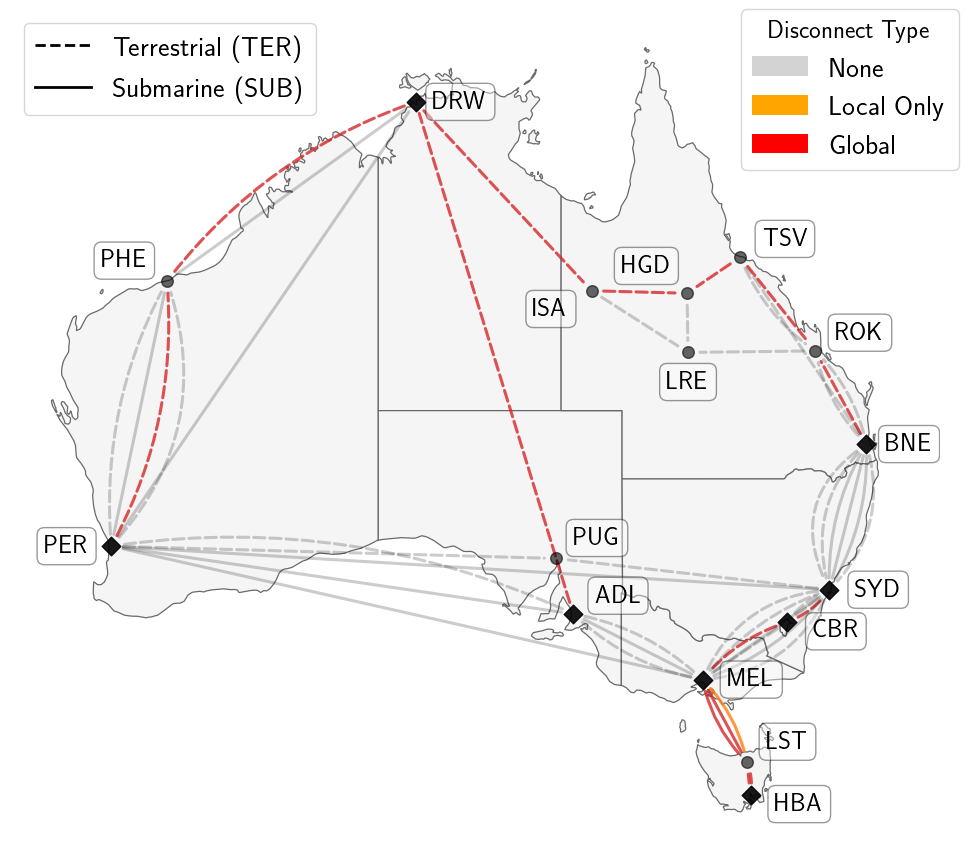

In [39]:
# import packages
import os
import re
import math
import urllib.request
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.lines import Line2D

# grab location for AUS state outline
NE_ADMIN1_POLY_ZIP = "https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces.zip"
NE_ADMIN1_POLY_LOCAL = "ne_50m_admin_1_states_provinces.zip"

POS_ADJUST = {'ADL_1': (2.2,0.8), 'BNE_1': (2.1,0), 'CBR_1': (2.4,-0.4), 'DRW_1': (2.2,0), 'HBA_1': (2.4,-0.4), 'MEL_1': (2.4,0), 'PER_1': (-2.2,0), 'SYD_1': (2.4,0), 'LST_1': (2,0.9), 'PHE_1': (-2.1,0.9), 'TSV_1': (2.2,0.8), 'ROK_1': (2.2,0.8), 'ISA_1': (-2,-0.8), 'HGD_1': (-2,1.2), 'LRE_1': (0,-1.3), 'PUG_1': (2,0.9)}

# custom edge styles for this map
TER_EDGE_STYLES = {'sub': '-', 'road': '--', 'rail': '--', 'rail_road': '--', 'mix': '-.'}
TER_EDGE_LABELS = {'sub': 'Submarine (SUB)', 'road': 'Terrestrial (TER)', 'rail': 'Terrestrial (TER)', 'rail_road': 'Terrestrial (TER)', 'mix': 'Mix'}

# font sizes
plt.rcParams.update({
    "font.size": 18,        # base size
    # "axes.titlesize": 18,
    # "axes.labelsize": 20,
    # "xtick.labelsize": 16,
    # "ytick.labelsize": 16,
    "legend.fontsize": 20,
    "text.usetex": True,
    "font.family": "sans-serif",
    # "font.serif": ["Computer Modern Roman"],
})

# function: load AUS state outline
def load_au_state_polygons():
    if not os.path.exists(NE_ADMIN1_POLY_LOCAL):
        print("Downloading Natural Earth admin-1 state polygons...")
        urllib.request.urlretrieve(NE_ADMIN1_POLY_ZIP, NE_ADMIN1_POLY_LOCAL)

    gdf = gpd.read_file(f"zip://{os.path.abspath(NE_ADMIN1_POLY_LOCAL)}").to_crs("EPSG:4326")

    if "adm0_a3" in gdf.columns:
        gdf = gdf[gdf["adm0_a3"].astype(str).str.upper() == "AUS"]
    elif "admin" in gdf.columns:
        gdf = gdf[gdf["admin"].astype(str).str.lower() == "australia"]
    elif "ADMIN" in gdf.columns:
        gdf = gdf[gdf["ADMIN"].astype(str).str.lower() == "australia"]

    return gdf

# function: get lat and lon values
def safe_pos(G):
    pos = {}
    for n, d in G.nodes(data=True):
        lon, lat = d.get("lon"), d.get("lat")
        try:
            lon, lat = float(lon), float(lat)
        except (TypeError, ValueError):
            continue
        if math.isfinite(lon) and math.isfinite(lat):
            pos[n] = (lon, lat)
    return pos

def site_pair(u, v):
    a, b = u[0], v[0]
    return (a, b) if a <= b else (b, a)

# function: remove edges based on filter
def filter_edges(G):
    out = []
    # go through edges and append
    for u, v, k, d in G.edges(keys=True, data=True):
        if d.get("edge_type") in {"attach", "interconnect"}: # SPECIFY FILTER HERE
            continue
        out.append((u, v, k, d))
    return out

# function: create the srg plot
def plot_srg_fail_map(G,srg_sum_df):
    # load au states
    au_states = load_au_state_polygons()

    # get lat/lon values
    pos = safe_pos(G)

    # grab filtered edges
    edges = [(u, v, k, d) for (u, v, k, d) in filter_edges(G) if u in pos and v in pos]

    labels = nx.get_node_attributes(G, 'city')
    abr_labels = {}
    # create abbreviation labels
    for ke in labels.keys():
        ke_abr = ke[:-2]
        abr_labels[ke] = ke_abr

    print(labels)
    print(abr_labels)

    fig, ax = plt.subplots(figsize=(12, 12))

    # basemap
    au_states.plot(ax=ax, color="whitesmoke", edgecolor="dimgray", linewidth=0.9, zorder=0)

    # nodes - IXPs as diamonds, regional as smaller dots
    # first get two lists of the nodes
    node_types = nx.get_node_attributes(G, 'kind')
    ixp_nodes = [key for key, val in node_types.items() if str(val) == 'MPoP']
    regional_nodes = [key for key, val in node_types.items() if str(val) == 'regional']

    # draw nodes for ixps
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        nodelist=ixp_nodes,
        node_size=90,
        node_color="black",
        node_shape="D",
        alpha=0.9
    )

    # draw nodes for regional
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        nodelist=regional_nodes,
        node_size=70,
        node_color="black",
        alpha=0.6
    )

    # city labels offset slightly north for readability
    label_pos = {n: (pos[n][0], pos[n][1] + 0.8) for n in G.nodes}
    # nx.draw_networkx_labels(
    #     G, label_pos, ax=ax,
    #     labels=labels,
    #     font_size=12,
    #     bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.8)
    # )

    seen = defaultdict(int)
    for u, v, k, d in edges:
        pair = (u, v) if str(u) <= str(v) else (v, u)
        i = seen[pair]
        seen[pair] += 1

        # calculate curvature: 0 for first edge, then alternate sides with increasing radius
        rad = 0.0 if i == 0 else (0.15 * ((i + 1) // 2)) * (1 if i % 2 == 1 else -1)

        # draw edges differently (if sub, rail, road, rail-road)
        # first determine type
        srg_type = d.get("srg_type")
        edge_style = TER_EDGE_STYLES[srg_type]

        # determine edge colour by looking up srg and finding how many times involved in global or local failure
        local_count = srg_sum_df.loc[srg_sum_df['srg_id'] == k, 'local_outages'].iloc[0]
        global_count = srg_sum_df.loc[srg_sum_df['srg_id'] == k, 'global_outages'].iloc[0]
        if global_count > 0:
            edge_colour = 'tab:red'
            alpha = 0.8
        elif local_count > 2:
            edge_colour = 'tab:orange'
            alpha = 0.8
        else:
            edge_colour = 'black'
            alpha = 0.2

        # then draw the edge
        nx.draw_networkx_edges(
            G, pos, ax=ax,
            edgelist=[(u, v)],
            arrows=True,
            connectionstyle=f"arc3,rad={rad}",
            width=2.2,
            alpha=alpha,
            edge_color=edge_colour,
            style=edge_style
        )

    label_pos = {n: (pos[n][0] + POS_ADJUST[n][0], pos[n][1] + POS_ADJUST[n][1]) for n in G.nodes}

    nx.draw_networkx_labels(
        G, label_pos, ax=ax,
        labels=abr_labels,
        font_size=18,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black", alpha=0.4)
    )

    # Create legend entries for each edge type
    # legend_lines = [
    #     Line2D([0], [0], lw=2, linestyle=EDGE_STYLES[stype], label=EDGE_LABELS[stype], color = 'black')
    #     for stype in sorted(EDGE_COLOURS.keys()) if stype !='rail' and stype !='mix'
    # ]
    legend_lines = [
        Line2D([0], [0], lw=2, linestyle=TER_EDGE_STYLES[stype], label=TER_EDGE_LABELS[stype], color = 'black')
        for stype in sorted(EDGE_COLOURS.keys()) if stype !='rail' and stype !='mix' and stype !='road'
    ]

    first_legend = ax.legend(handles=legend_lines, loc="upper left")

    # 2. Add the first legend manually as an artist
    ax.add_artist(first_legend)

    # add legend for disconnect type
    # Legend
    status_colours = {
        "None": "lightgrey",
        "Local Only": "orange",
        "Global": "red",
    }

    status_order = list(status_colours.keys())

    handles = [Patch(facecolor=status_colours[c], edgecolor="none", label=c) for c in status_order]

    ax.legend(
        handles=handles[:3],
        title="Disconnect Type",
        bbox_to_anchor=(1.02, 1),
        loc="upper right",
        borderaxespad=0
    )


    x_min, x_max = ax.get_xlim()
    ax.set_xlim(x_min, x_max + 1)
    ax.axis("off")
    plt.savefig(f"images/c_fail_map.pdf", bbox_inches='tight', transparent=True)
    plt.savefig(f"images/c_fail_map.svg", bbox_inches='tight', transparent=True)
    plt.show()


plot_srg_fail_map(G_srg_c,srg_sum_c_df)
# plot_srg_fail_map(G_srg_i,srg_sum_i_df)


## Rail vs Road vs Sub

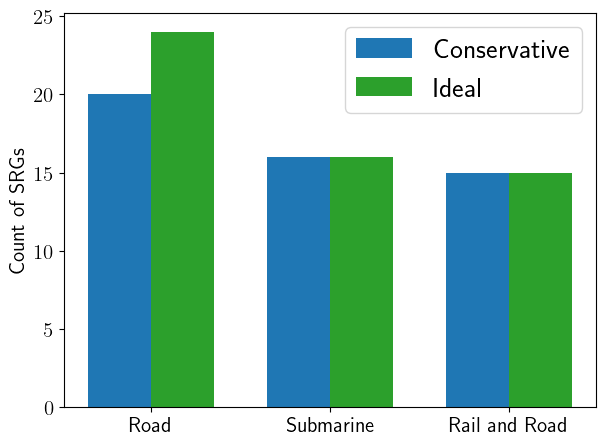

In [40]:
# intial bar plot 
def rail_road_bar(srg_df1,srg_df2):
    counts1 = srg_df1['srg_type'].value_counts()
    counts2 = srg_df2['srg_type'].value_counts()
    labels = ['Road', 'Submarine', 'Rail and Road']

    x = np.arange(len(labels))
    width = 0.35
    
    fig, ax = plt.subplots()
    ax.bar(x - width/2, counts1, width, label='Conservative', color='tab:blue')
    ax.bar(x + width/2, counts2, width, label='Ideal', color='tab:green')

    ax.set_ylabel('Count of SRGs')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.legend()
    plt.tight_layout()
    plt.show()


rail_road_bar(srg_c_df,srg_i_df)

## Number of edges to begin with for each ISP, then for each SRG

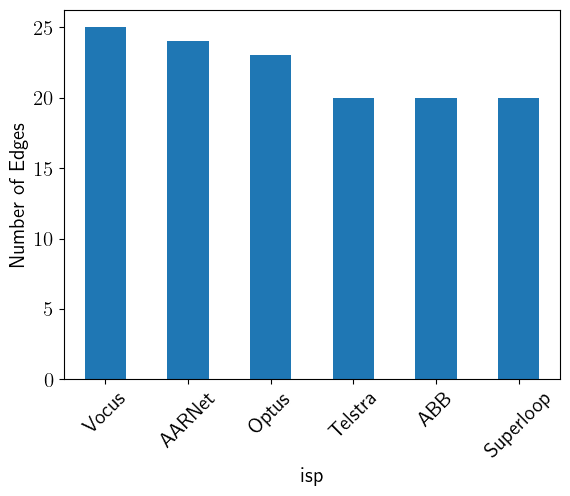

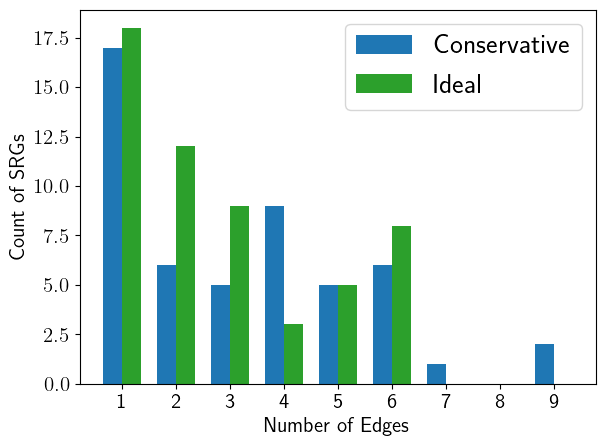

In [41]:
# ISP edge bar plot

def edge_count_bar(edge_df):
    counts = edge_df['isp'].value_counts()

    counts.plot(kind='bar', color='tab:blue')
    plt.ylabel('Number of Edges')
    plt.xticks(ticks=range(len(counts)), labels=[ISP_LABELS.get(isp, isp) for isp in counts.index], rotation=45) 
    plt.show()

def srg_edge_count_bar(srg_dfc,srg_dfi):
    dfc = srg_dfc.copy()
    dfi = srg_dfi.copy()

    dfc['edge_count'] = dfc['edges'].apply(len)
    dfi['edge_count'] = dfi['edges'].apply(len)

    countsc = dfc['edge_count'].value_counts().sort_index()
    countsi = dfi['edge_count'].value_counts().sort_index()

    # Get all unique edge counts and create complete range
    all_indices = sorted(set(countsc.index.tolist() + countsi.index.tolist()))
    full_range = np.arange(min(all_indices), max(all_indices) + 1)

    # Reindex both to the same full range
    countsc = countsc.reindex(full_range, fill_value=0)
    countsi = countsi.reindex(full_range, fill_value=0)

    x = np.arange(len(full_range))
    width = 0.35
    
    fig, ax = plt.subplots()
    ax.bar(x - width/2, countsc.values, width, label='Conservative', color='tab:blue')
    ax.bar(x + width/2, countsi.values, width, label='Ideal', color='tab:green')

    ax.set_ylabel('Count of SRGs')
    ax.set_xlabel('Number of Edges')
    ax.set_xticks(x)
    ax.set_xticklabels(full_range)
    ax.legend()
    plt.tight_layout()
    plt.show()

edge_count_bar(edge_df)
srg_edge_count_bar(srg_c_df,srg_i_df)

## Compare conservative to ideal metrics

In [42]:
# proportion of pairs causing local disconnect
# proportion of pairs causing any disconnect
# mean proportion of ISPs affected
# mean proportion